# LOST - Continuous Mountain Car

In [1]:
import numpy as np
import gymnasium as gym
import random 

In [2]:
# Cambiar render_mode a rgb_array para entrenar/testear sino human
env_id = 'MountainCarContinuous-v0'
env = gym.make(env_id, render_mode='rgb_array')

In [3]:
from q_learning_agent import QLearningAgent

Observation Space

In [4]:
env.observation_space

Box([-1.2  -0.07], [0.6  0.07], (2,), float32)

Action Space

In [5]:
env.action_space

Box(-1.0, 1.0, (1,), float32)

Discretización de los estados

In [6]:
x_space = np.linspace(-1.2, 0.6, 100)
vel_space = np.linspace(-0.07, 0.07, 100)
x_space

array([-1.2       , -1.18181818, -1.16363636, -1.14545455, -1.12727273,
       -1.10909091, -1.09090909, -1.07272727, -1.05454545, -1.03636364,
       -1.01818182, -1.        , -0.98181818, -0.96363636, -0.94545455,
       -0.92727273, -0.90909091, -0.89090909, -0.87272727, -0.85454545,
       -0.83636364, -0.81818182, -0.8       , -0.78181818, -0.76363636,
       -0.74545455, -0.72727273, -0.70909091, -0.69090909, -0.67272727,
       -0.65454545, -0.63636364, -0.61818182, -0.6       , -0.58181818,
       -0.56363636, -0.54545455, -0.52727273, -0.50909091, -0.49090909,
       -0.47272727, -0.45454545, -0.43636364, -0.41818182, -0.4       ,
       -0.38181818, -0.36363636, -0.34545455, -0.32727273, -0.30909091,
       -0.29090909, -0.27272727, -0.25454545, -0.23636364, -0.21818182,
       -0.2       , -0.18181818, -0.16363636, -0.14545455, -0.12727273,
       -0.10909091, -0.09090909, -0.07272727, -0.05454545, -0.03636364,
       -0.01818182,  0.        ,  0.01818182,  0.03636364,  0.05

Obtener el estado a partir de la observación

In [7]:
def get_state(obs):
    x, vel = obs
    x_bin = np.digitize(x, x_space)
    vel_bin = np.digitize(vel, vel_space)
    return x_bin, vel_bin

In [8]:
state = get_state(np.array([-0.4, 0.02]))
state

(np.int64(45), np.int64(64))

Discretización de las acciones

In [9]:
actions = list(np.linspace(-1, 1, 10))
actions

[np.float64(-1.0),
 np.float64(-0.7777777777777778),
 np.float64(-0.5555555555555556),
 np.float64(-0.33333333333333337),
 np.float64(-0.11111111111111116),
 np.float64(0.11111111111111116),
 np.float64(0.33333333333333326),
 np.float64(0.5555555555555554),
 np.float64(0.7777777777777777),
 np.float64(1.0)]

In [10]:
def get_sample_action():
    return random.choice(actions)

Inicilización de la tabla Q

In [11]:
Q = np.zeros((len(x_space) + 1, len(vel_space) + 1, len(actions)))
Q

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

Obtención de la acción a partir de la tabla Q

In [12]:
def optimal_policy(state, Q):
    action = actions[np.argmax(Q[state])]
    return action

Epsilon-Greedy Policy

In [13]:
def epsilon_greedy_policy(state, Q, epsilon=0.1):
    explore = np.random.binomial(1, epsilon)
    if explore:
        action = get_sample_action()
    else:
        action = optimal_policy(state, Q)
        
    return action

# Prueba q quedó

In [ ]:
# Testear el agente entrenado (sin exploración)
print("\nTesteando agente entrenado...")
from dyna_q_agent import DynaQAgent
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='human')
test_rewards, test_steps = agent.test_agent(env, episodes=3, render=True)
env.close()

print(f"\nPromedio de rewards en testing: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps en testing: {np.mean(test_steps):.2f}")

# Q-Learning Agent

In [15]:
from q_learning_agent import QLearningAgent

In [16]:
from q_experiments_manager import ExperimentManager

# 1. Crear el entorno
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

# 2. Inicializar el mánager de experimentos
manager = ExperimentManager()

In [ ]:
print("Entrenando agente Q-Learning...")
id_1 = "8k_episodes_eps015"
manager.train_run(
    env=env, 
    run_id=id_1,
    x_bins=100,         
    vel_bins=100,       
    action_bins=20,    
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamient0
manager.plot_training_history(id_1)

# DynaQAgent

In [ ]:
from dyna_q_agent import DynaQAgent

In [ ]:
# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [ ]:
# Cargar un modelo Dyna-Q guardado y evaluarlo
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Evaluando el modelo cargado...")
test_rewards, test_steps, success_count = agent.test_agent(env, episodes=5, render=False)
env.close()

print(f"\nExitos en testing: {success_count}/5")
print(f"Promedio de rewards: {np.mean(test_rewards):.2f}")
print(f"Promedio de steps: {np.mean(test_steps):.2f}")

# Q-Learning variando el epsilon

In [ ]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')

In [ ]:
print("Entrenando agente Q-Learning...")
id_e1 = "8k_episodes_eps075"
manager.train_run(
    env, 
    run_id=id_e1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.075,
    max_steps=3000,
)
env.close()
manager.plot_training_history(id_e1)

In [ ]:
# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e2 = "8k_episodes_eps025"
manager.train_run(
    env, 
    run_id=id_e2,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.025,
    max_steps=3000,
)
env.close()
manager.plot_training_history(id_e2)

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e3 = "8k_episodes_eps001"
manager.train_run(
    env, 
    run_id=id_e3,
    x_bins=100,
    vel_bins=100,    
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_e3)

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_e4 = "5500_episodes_eps0005"
manager.train_run(
    env, 
    run_id=id_e4,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=5500,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_e4)

Variando el epsilon start

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
id_es1= "8k_episodes_eps075"
manager.train_run(
    env, 
    run_id=id_es1,
    x_bins=100,
    vel_bins=100,
    action_bins=20,
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.75, 
    epsilon_end=0.025,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_es1)

Comparacion de graficas

In [ ]:
manager.plot_comparisons()

# Analsis para mejorar dicretización

## Q-learning

### Setup

In [14]:
import gymnasium as gym
from q_experiments_manager import ExperimentManager
from q_learning_agent import QLearningAgent
from discretization_evaluator import DiscretizationEvaluator

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
manager = ExperimentManager()

In [ ]:
evaluator = DiscretizationEvaluator(manager)

train_kwargs = {
    'episodes': 5000,
    'alpha': 0.05,
    'gamma': 0.99,
    'epsilon_start': 0.99,
    'epsilon_end': 0.0005,
    'max_steps': 3000,
}

### Pruebas variando los action Bins

In [ ]:
evaluator.evaluate_group(
    env=env,
    x_bins_list=[50],
    vel_bins_list=[50],
    action_bins_list=[5, 10, 20],  
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=3000,
    prefix="G1_Acciones"
)

In [ ]:
evaluator.plot_ranking()

### Variaciones con mejor resultado anterior

In [ ]:
evaluator.evaluate_group(
    env=env,
    x_bins_list=[30, 100],      # <--- Baja y alta resolución de posición
    vel_bins_list=[20, 100],     # <--- Baja y alta resolución de velocidad
    action_bins_list=[10],       # Fijamos el ganador tentativo del grupo anterior
    train_kwargs=train_kwargs,
    test_episodes=10,
    test_max_steps=3000,
    prefix="G2_Estados"
)

env.close()

In [ ]:
print("\n*** PROCESANDO RESULTADOS DE LOS GRUPOS EJECUTADOS ***")
evaluator.print_summary()

## Gráficas

In [ ]:
evaluator.plot_heatmap(metric='avg_reward')
evaluator.plot_pareto(metric='avg_reward')
evaluator.plot_convergence(top_n=3)

# Con los valores resultantes

30, 20 y 10

Entrenando agente Q-Learning...

[4k_episodes_eps015] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[4k_episodes_eps015] Ep 800/4000 - Avg Reward: -94.61, Steps: 3000
[4k_episodes_eps015] Ep 1600/4000 - Avg Reward: -64.33, Steps: 2111
[4k_episodes_eps015] Ep 2400/4000 - Avg Reward: 28.20, Steps: 426
[4k_episodes_eps015] Ep 3200/4000 - Avg Reward: 84.59, Steps: 379
[4k_episodes_eps015] Ep 4000/4000 - Avg Reward: 91.73, Steps: 149
--> Experimento '4k_episodes_eps015' guardado con éxito en el historial.


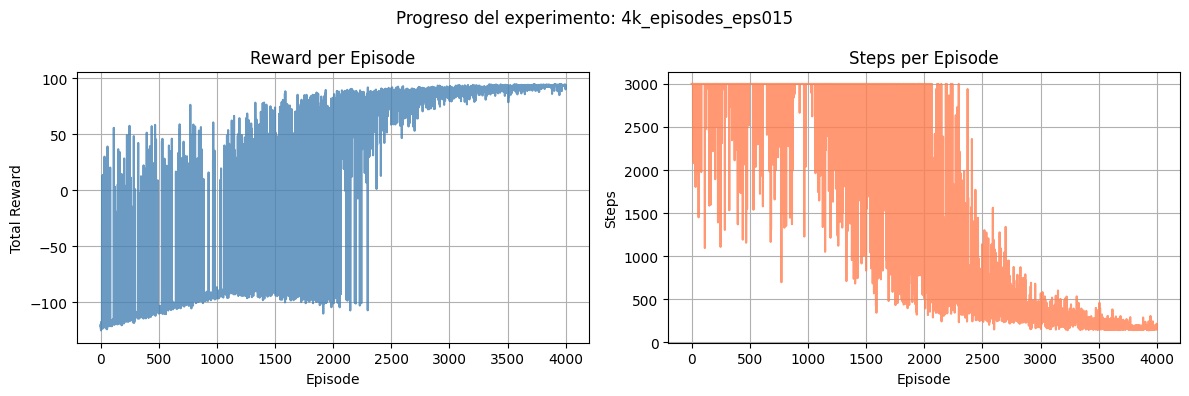

In [17]:
print("Entrenando agente Q-Learning...")
id_a1 = "4k_episodes_eps015"
manager.train_run(
    env=env, 
    run_id=id_a1,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.0005,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamient0
manager.plot_training_history(id_a1)

## Dyna Q con los valores

In [18]:
from dyna_q_experiments_manager import DynaQExperimentManager

dyna_manager = DynaQExperimentManager()


[dyna_4k_episodes_eps015] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=30
[dyna_4k_episodes_eps015] Ep 800/4000 - Avg Reward: -89.27, Steps: 3000, Success: 23.6%
[dyna_4k_episodes_eps015] Ep 1600/4000 - Avg Reward: -14.48, Steps: 1344, Success: 69.9%
[dyna_4k_episodes_eps015] Ep 2400/4000 - Avg Reward: 61.95, Steps: 495, Success: 99.5%
[dyna_4k_episodes_eps015] Ep 3200/4000 - Avg Reward: 82.79, Steps: 238, Success: 100.0%
[dyna_4k_episodes_eps015] Ep 4000/4000 - Avg Reward: 89.37, Steps: 166, Success: 100.0%
--> Experimento 'dyna_4k_episodes_eps015' guardado con éxito en el historial.


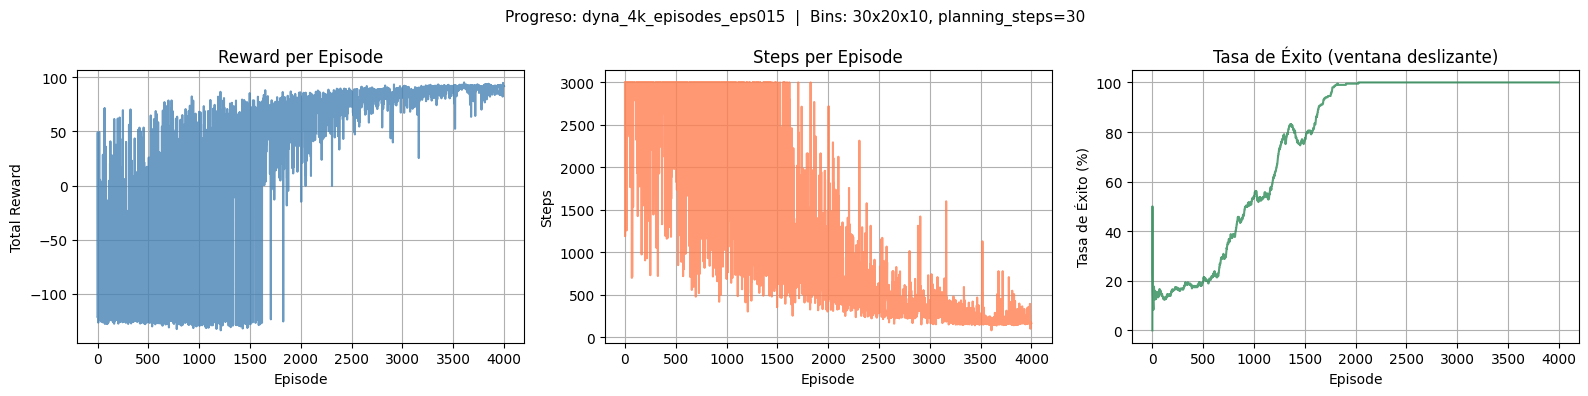

In [19]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d1 = "dyna_4k_episodes_eps015"
dyna_manager.train_run(
    env=env,
    run_id=id_d1,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=30,
    episodes=4000,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d1)


[dyna_2.5k_episodes_planning30] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=30
[dyna_2.5k_episodes_planning30] Ep 500/2500 - Avg Reward: -89.16, Steps: 2126, Success: 24.2%
[dyna_2.5k_episodes_planning30] Ep 1000/2500 - Avg Reward: -9.74, Steps: 761, Success: 73.0%
[dyna_2.5k_episodes_planning30] Ep 1500/2500 - Avg Reward: 62.47, Steps: 286, Success: 99.2%
[dyna_2.5k_episodes_planning30] Ep 2000/2500 - Avg Reward: 82.51, Steps: 262, Success: 100.0%
[dyna_2.5k_episodes_planning30] Ep 2500/2500 - Avg Reward: 88.84, Steps: 245, Success: 100.0%
--> Experimento 'dyna_2.5k_episodes_planning30' guardado con éxito en el historial.


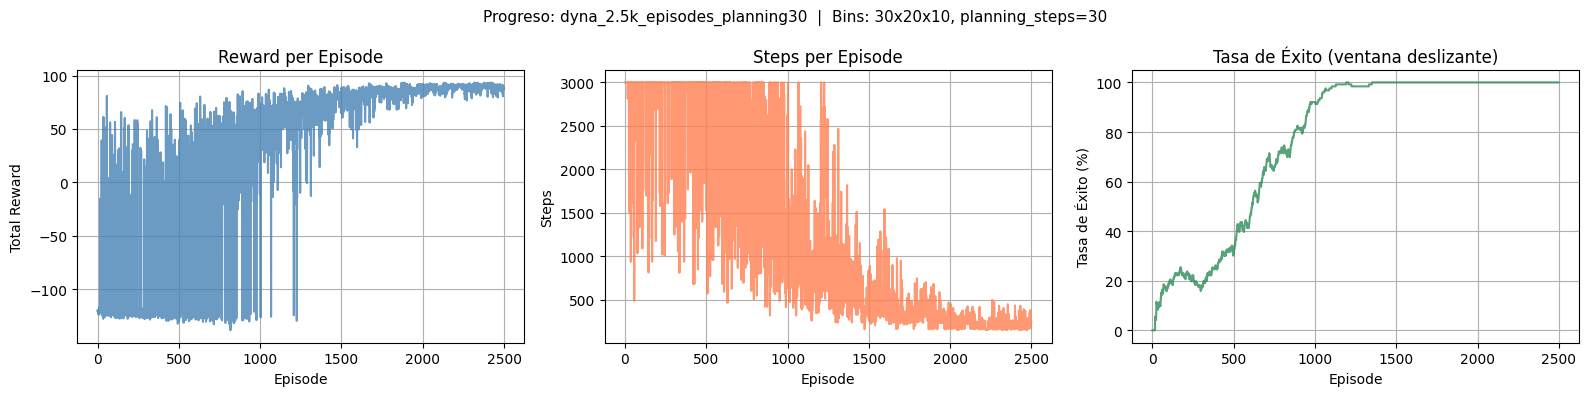

In [20]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d1 = "dyna_2.5k_episodes_planning30"
dyna_manager.train_run(
    env=env,
    run_id=id_d1,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=30,
    episodes=2500,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d1)

#### Bajando los planning steps


[dyna_2.5k_episodes_planning15] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=15
[dyna_2.5k_episodes_planning15] Ep 500/2500 - Avg Reward: -72.30, Steps: 2729, Success: 35.2%
[dyna_2.5k_episodes_planning15] Ep 1000/2500 - Avg Reward: 27.18, Steps: 554, Success: 90.8%
[dyna_2.5k_episodes_planning15] Ep 1500/2500 - Avg Reward: 75.47, Steps: 336, Success: 100.0%
[dyna_2.5k_episodes_planning15] Ep 2000/2500 - Avg Reward: 85.55, Steps: 340, Success: 100.0%
[dyna_2.5k_episodes_planning15] Ep 2500/2500 - Avg Reward: 90.69, Steps: 159, Success: 100.0%
--> Experimento 'dyna_2.5k_episodes_planning15' guardado con éxito en el historial.


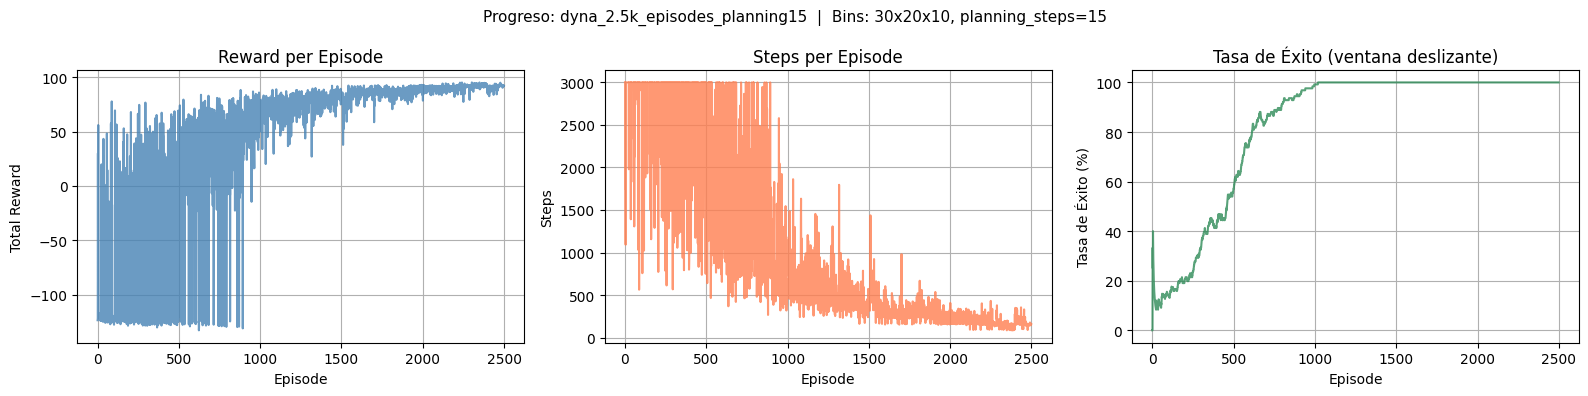

In [ ]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d3 = "dyna_2.5k_episodes_planning15"
dyna_manager.train_run(
    env=env,
    run_id=id_d3,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=15,
    episodes=2500,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d3)


[dyna_2.5k_episodes_planning5] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=5
[dyna_2.5k_episodes_planning5] Ep 500/2500 - Avg Reward: -36.49, Steps: 374, Success: 53.8%
[dyna_2.5k_episodes_planning5] Ep 1000/2500 - Avg Reward: 70.54, Steps: 434, Success: 100.0%
[dyna_2.5k_episodes_planning5] Ep 1500/2500 - Avg Reward: 84.54, Steps: 310, Success: 100.0%
[dyna_2.5k_episodes_planning5] Ep 2000/2500 - Avg Reward: 89.64, Steps: 151, Success: 100.0%
[dyna_2.5k_episodes_planning5] Ep 2500/2500 - Avg Reward: 91.12, Steps: 78, Success: 100.0%
--> Experimento 'dyna_2.5k_episodes_planning5' guardado con éxito en el historial.


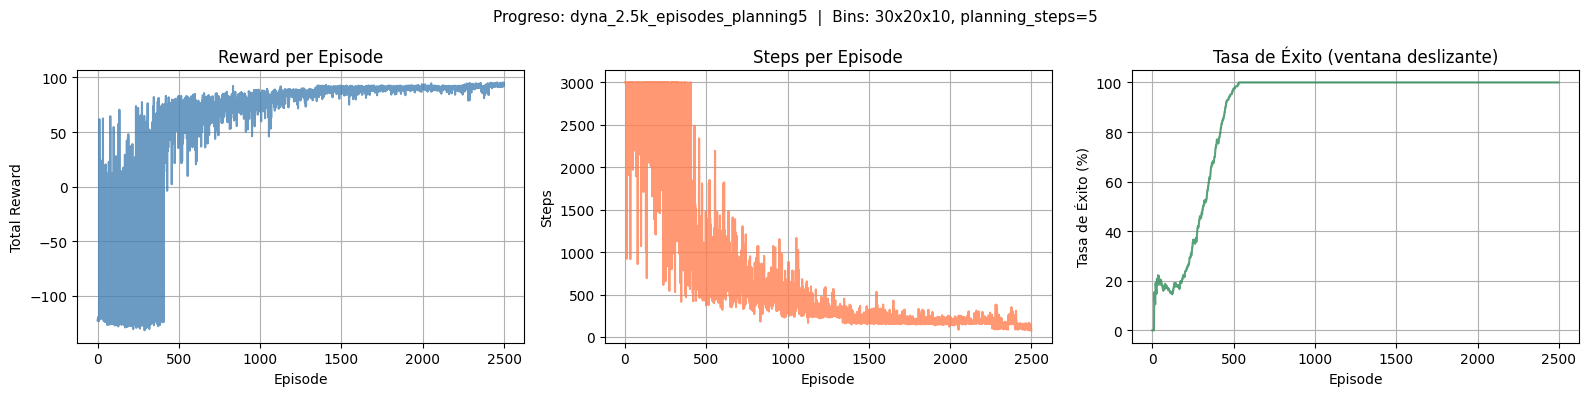

In [22]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d3 = "dyna_2.5k_episodes_planning5"
dyna_manager.train_run(
    env=env,
    run_id=id_d3,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=5,
    episodes=2500,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d3)

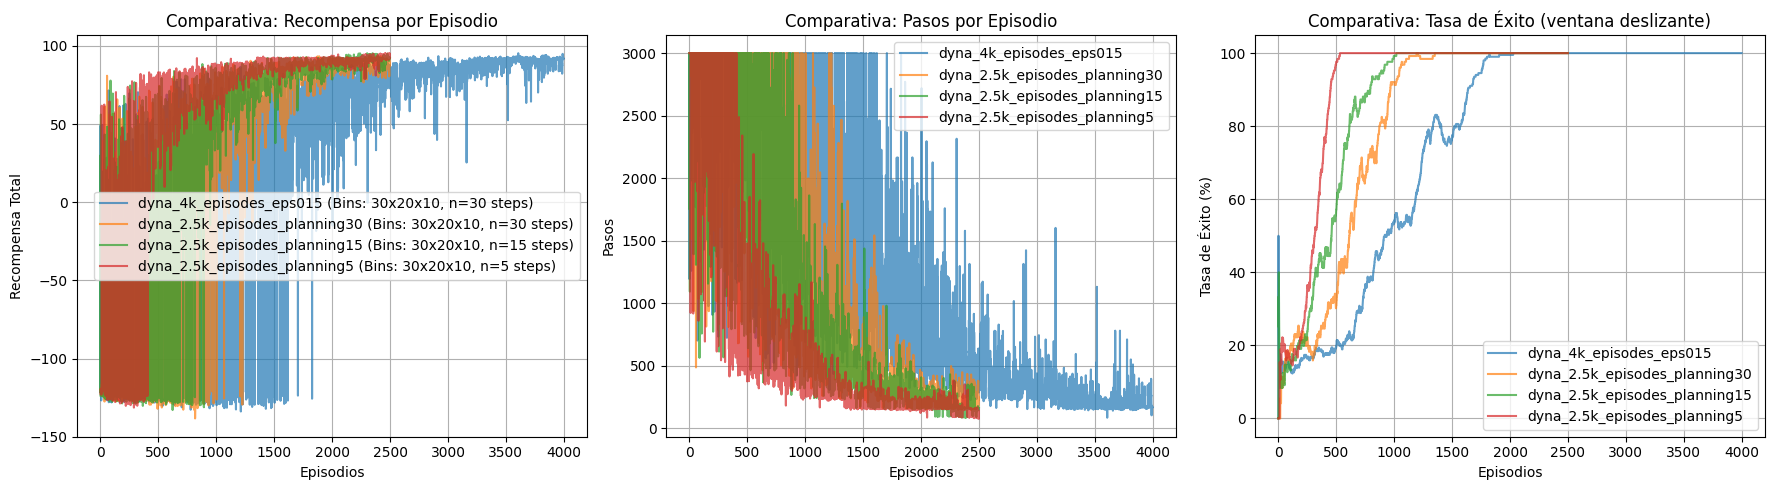

In [23]:
dyna_manager.plot_comparisons()

Con el mejor resultado menor cantidad de episodios


[dyna_2k_episodes_planning5] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=5
[dyna_2k_episodes_planning5] Ep 400/2000 - Avg Reward: -42.56, Steps: 686, Success: 53.2%
[dyna_2k_episodes_planning5] Ep 800/2000 - Avg Reward: 65.90, Steps: 700, Success: 99.2%
[dyna_2k_episodes_planning5] Ep 1200/2000 - Avg Reward: 84.08, Steps: 387, Success: 100.0%
[dyna_2k_episodes_planning5] Ep 1600/2000 - Avg Reward: 89.22, Steps: 151, Success: 100.0%
[dyna_2k_episodes_planning5] Ep 2000/2000 - Avg Reward: 90.92, Steps: 91, Success: 100.0%
--> Experimento 'dyna_2k_episodes_planning5' guardado con éxito en el historial.


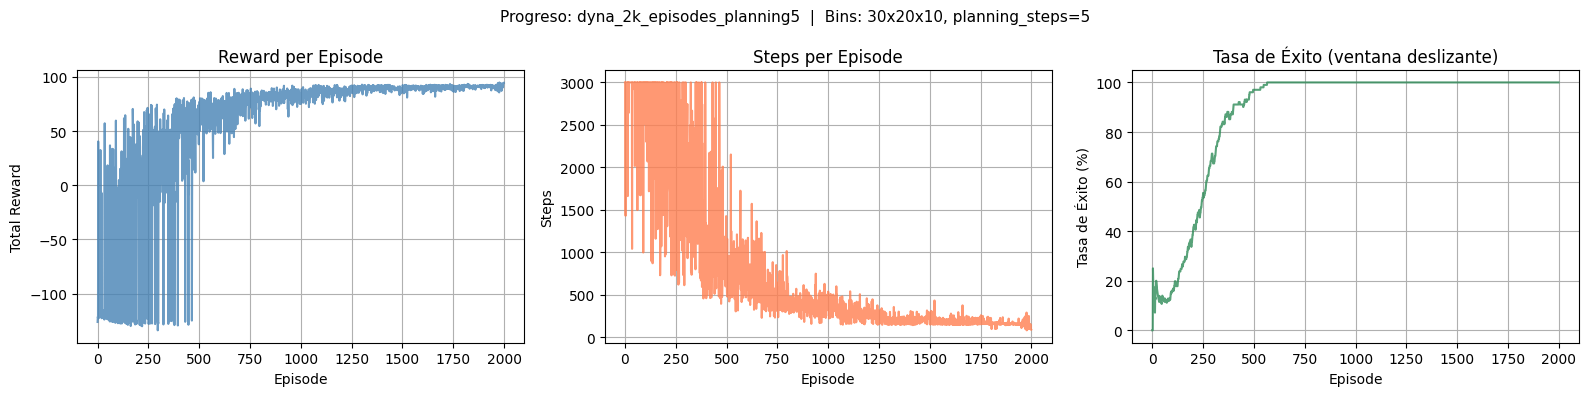

In [24]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d5 = "dyna_2k_episodes_planning5"
dyna_manager.train_run(
    env=env,
    run_id=id_d5,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=5,
    episodes=2000,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d5)


[dyna_1.6k_episodes_planning5] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=5
[dyna_1.6k_episodes_planning5] Ep 320/1600 - Avg Reward: -46.75, Steps: 1719, Success: 50.3%
[dyna_1.6k_episodes_planning5] Ep 640/1600 - Avg Reward: 62.39, Steps: 316, Success: 99.7%
[dyna_1.6k_episodes_planning5] Ep 960/1600 - Avg Reward: 83.20, Steps: 230, Success: 100.0%
[dyna_1.6k_episodes_planning5] Ep 1280/1600 - Avg Reward: 89.07, Steps: 226, Success: 100.0%
[dyna_1.6k_episodes_planning5] Ep 1600/1600 - Avg Reward: 90.82, Steps: 166, Success: 100.0%
--> Experimento 'dyna_1.6k_episodes_planning5' guardado con éxito en el historial.


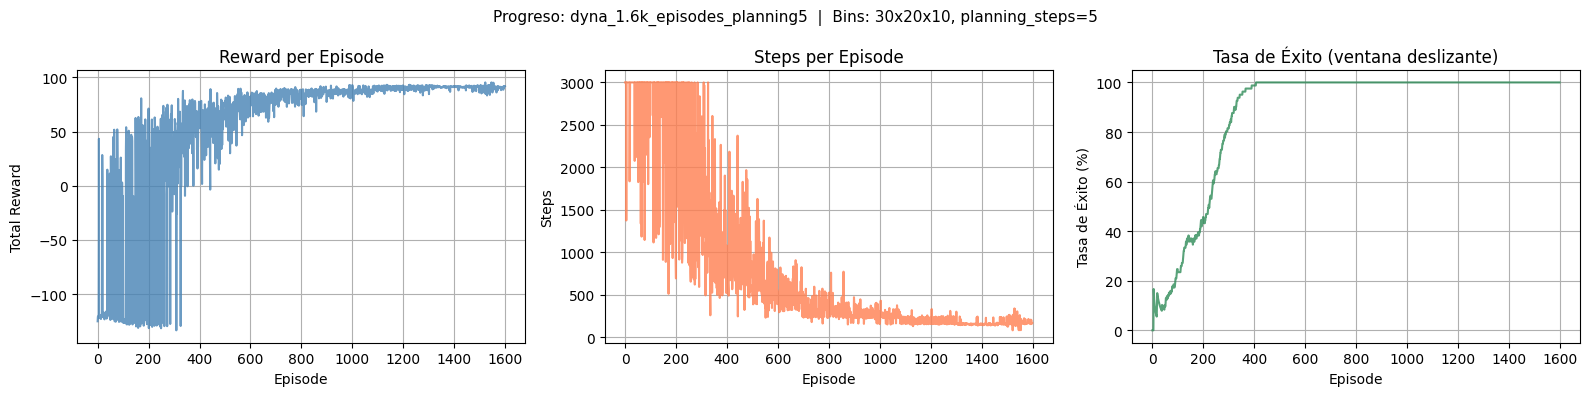

In [25]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d6 = "dyna_1.6k_episodes_planning5"
dyna_manager.train_run(
    env=env,
    run_id=id_d6,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=5,
    episodes=1600,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d6)

menos episodios y subir planinng step


[dyna_1k_episodes_planning15] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=15
[dyna_1k_episodes_planning15] Ep 200/1000 - Avg Reward: -81.16, Steps: 2048, Success: 29.5%
[dyna_1k_episodes_planning15] Ep 400/1000 - Avg Reward: 28.57, Steps: 552, Success: 89.5%
[dyna_1k_episodes_planning15] Ep 600/1000 - Avg Reward: 70.08, Steps: 541, Success: 99.5%
[dyna_1k_episodes_planning15] Ep 800/1000 - Avg Reward: 85.30, Steps: 224, Success: 100.0%
[dyna_1k_episodes_planning15] Ep 1000/1000 - Avg Reward: 90.08, Steps: 134, Success: 100.0%
--> Experimento 'dyna_1k_episodes_planning15' guardado con éxito en el historial.


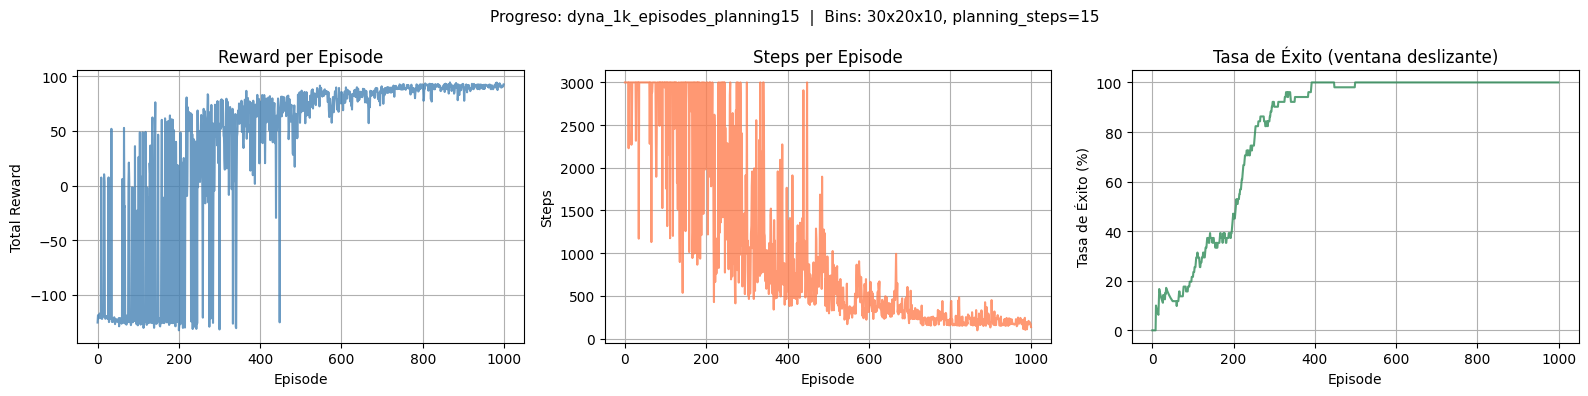

In [26]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d7 = "dyna_1k_episodes_planning15"
dyna_manager.train_run(
    env=env,
    run_id=id_d7,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=15,
    episodes=1000,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d7)


[dyna_800_episodes_planning15] Iniciando experimento con Q-Table de tamaño: (31, 21, 10), planning_steps=15
[dyna_800_episodes_planning15] Ep 160/800 - Avg Reward: -65.11, Steps: 3000, Success: 38.8%
[dyna_800_episodes_planning15] Ep 320/800 - Avg Reward: 25.79, Steps: 1582, Success: 90.6%
[dyna_800_episodes_planning15] Ep 480/800 - Avg Reward: 72.74, Steps: 402, Success: 100.0%
[dyna_800_episodes_planning15] Ep 640/800 - Avg Reward: 85.03, Steps: 151, Success: 100.0%
[dyna_800_episodes_planning15] Ep 800/800 - Avg Reward: 89.67, Steps: 161, Success: 100.0%
--> Experimento 'dyna_800_episodes_planning15' guardado con éxito en el historial.


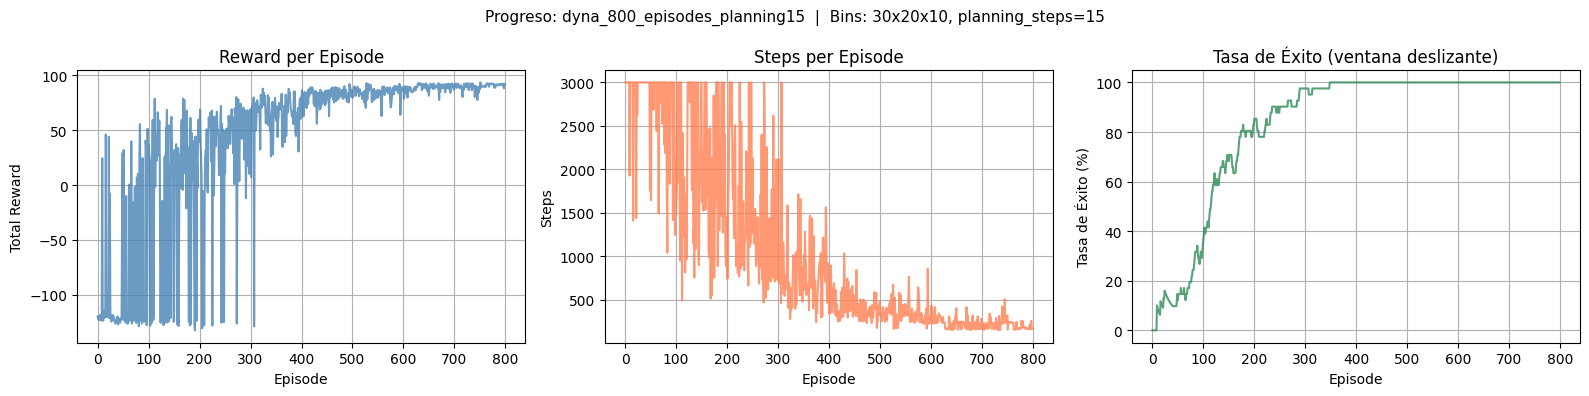

In [27]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d8 = "dyna_800_episodes_planning15"
dyna_manager.train_run(
    env=env,
    run_id=id_d8,
    x_bins=30, vel_bins=20, action_bins=10,
    planning_steps=15,
    episodes=800,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d8)

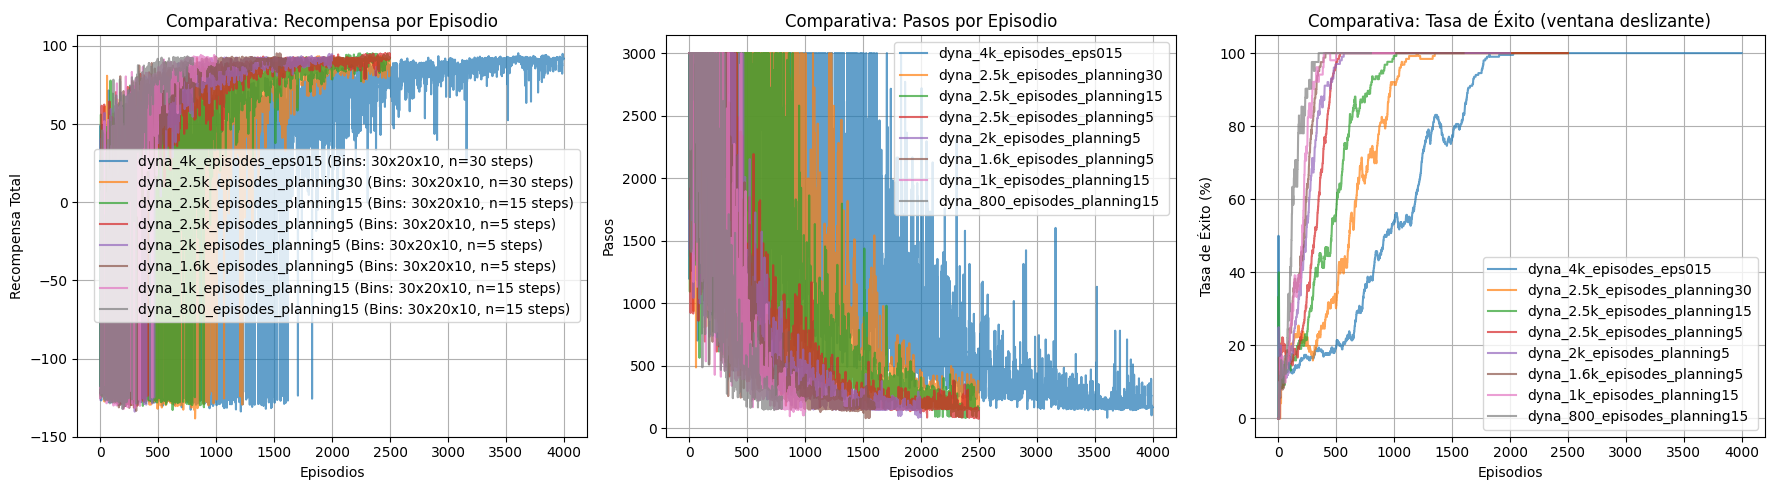

In [28]:
dyna_manager.plot_comparisons()

## Como funciona sin mejora de discretizacion


[dynaog_2k_episodes_planning5] Iniciando experimento con Q-Table de tamaño: (101, 101, 20), planning_steps=5
[dynaog_2k_episodes_planning5] Ep 400/2000 - Avg Reward: -78.61, Steps: 3000, Success: 17.0%
[dynaog_2k_episodes_planning5] Ep 800/2000 - Avg Reward: 0.19, Steps: 1328, Success: 61.5%
[dynaog_2k_episodes_planning5] Ep 1200/2000 - Avg Reward: 23.84, Steps: 1707, Success: 66.0%
[dynaog_2k_episodes_planning5] Ep 1600/2000 - Avg Reward: 53.50, Steps: 3000, Success: 78.2%
[dynaog_2k_episodes_planning5] Ep 2000/2000 - Avg Reward: 81.60, Steps: 1742, Success: 92.2%
--> Experimento 'dynaog_2k_episodes_planning5' guardado con éxito en el historial.


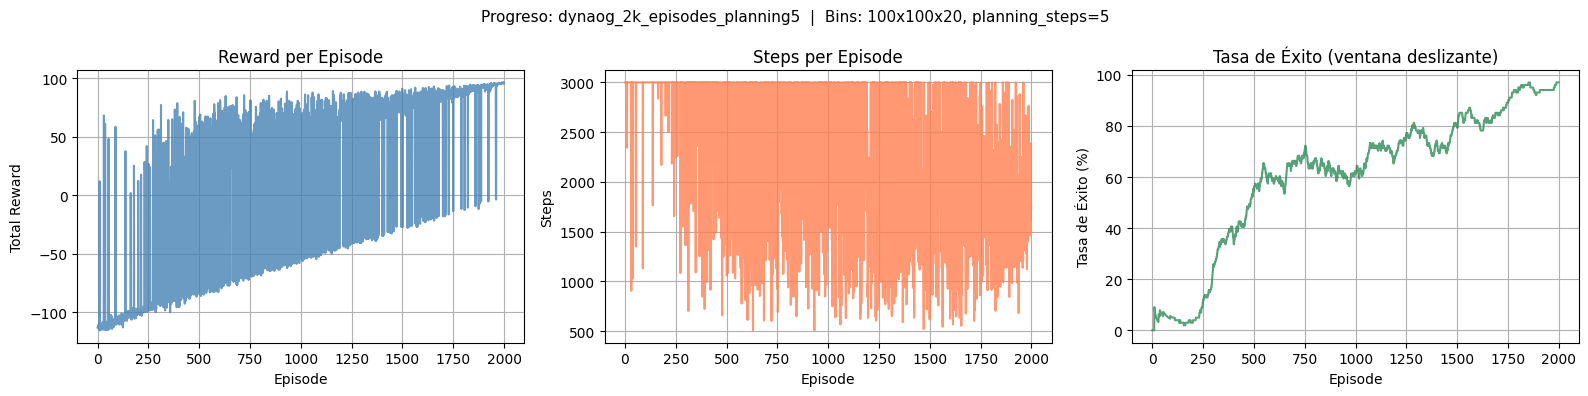

In [29]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d9 = "dynaog_2k_episodes_planning5"
dyna_manager.train_run(
    env=env,
    run_id=id_d9,
    x_bins=100, vel_bins=100, action_bins=20,
    planning_steps=5,
    episodes=2000,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d9)


[dynaog_1.5k_episodes_planning15] Iniciando experimento con Q-Table de tamaño: (101, 101, 20), planning_steps=15
[dynaog_1.5k_episodes_planning15] Ep 300/1500 - Avg Reward: -68.13, Steps: 3000, Success: 25.3%
[dynaog_1.5k_episodes_planning15] Ep 600/1500 - Avg Reward: 25.11, Steps: 3000, Success: 77.7%
[dynaog_1.5k_episodes_planning15] Ep 900/1500 - Avg Reward: 61.30, Steps: 515, Success: 92.3%
[dynaog_1.5k_episodes_planning15] Ep 1200/1500 - Avg Reward: 78.86, Steps: 1671, Success: 97.3%
[dynaog_1.5k_episodes_planning15] Ep 1500/1500 - Avg Reward: 89.51, Steps: 478, Success: 99.7%
--> Experimento 'dynaog_1.5k_episodes_planning15' guardado con éxito en el historial.


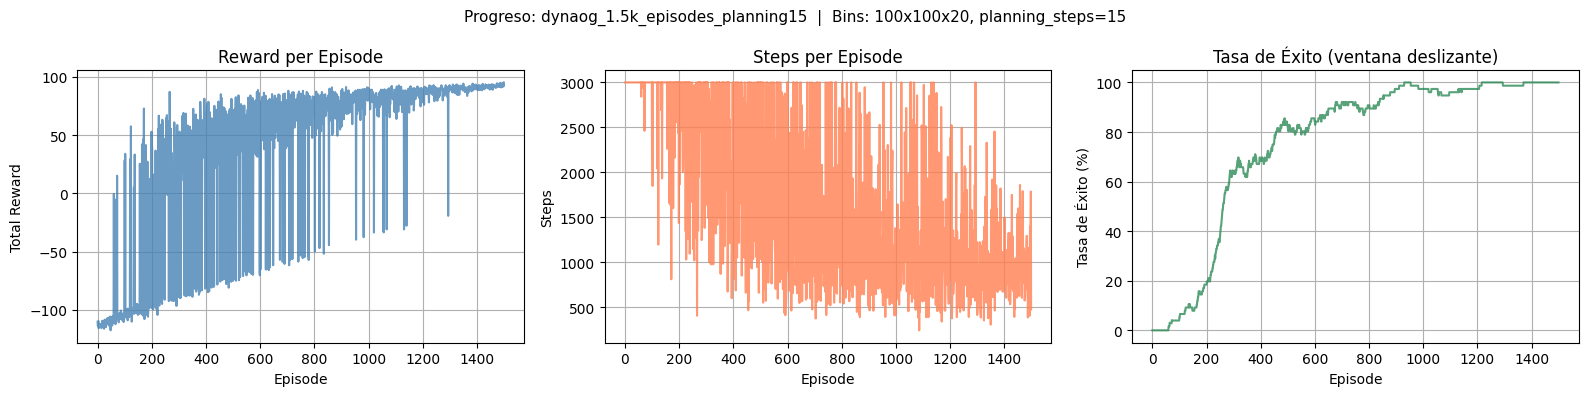

In [30]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d10 = "dynaog_1.5k_episodes_planning15"
dyna_manager.train_run(
    env=env,
    run_id=id_d10,
    x_bins=100, vel_bins=100, action_bins=20,
    planning_steps=15,
    episodes=1500,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=3000,
)
env.close()
dyna_manager.plot_training_history(id_d10)


[dynaog_1k_episodes_planning15] Iniciando experimento con Q-Table de tamaño: (101, 101, 20), planning_steps=15
[dynaog_1k_episodes_planning15] Ep 200/1000 - Avg Reward: -79.19, Steps: 1406, Success: 53.5%
[dynaog_1k_episodes_planning15] Ep 400/1000 - Avg Reward: 31.11, Steps: 2601, Success: 93.0%
[dynaog_1k_episodes_planning15] Ep 600/1000 - Avg Reward: 57.02, Steps: 1935, Success: 95.5%
[dynaog_1k_episodes_planning15] Ep 800/1000 - Avg Reward: 73.52, Steps: 1830, Success: 98.0%
[dynaog_1k_episodes_planning15] Ep 1000/1000 - Avg Reward: 87.99, Steps: 986, Success: 100.0%
--> Experimento 'dynaog_1k_episodes_planning15' guardado con éxito en el historial.


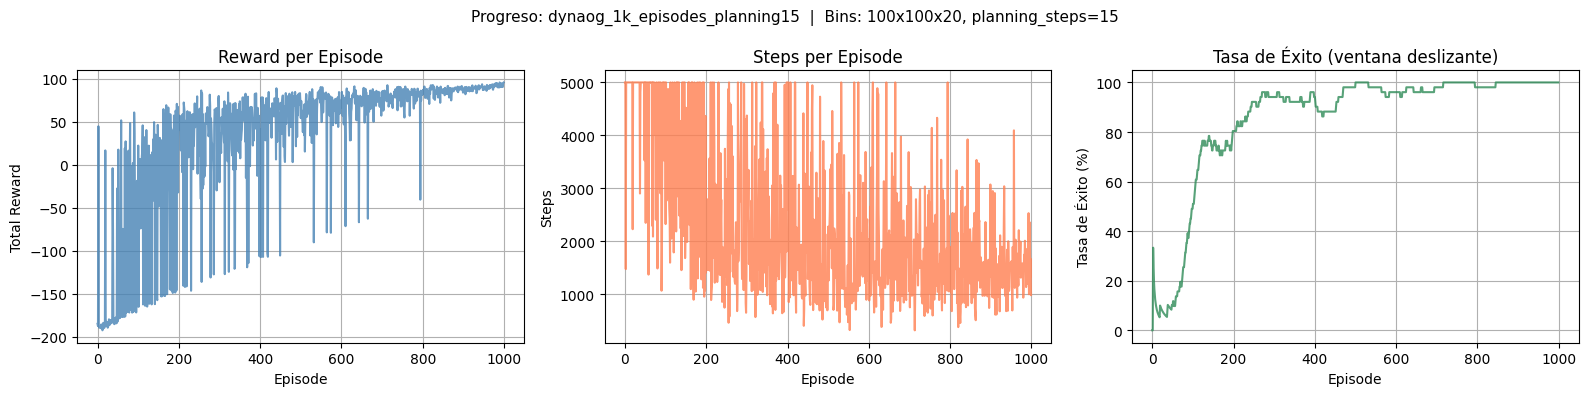

In [31]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d11 = "dynaog_1k_episodes_planning15"
dyna_manager.train_run(
    env=env,
    run_id=id_d11,
    x_bins=100, vel_bins=100, action_bins=20,
    planning_steps=15,
    episodes=1000,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=5000,
)
env.close()
dyna_manager.plot_training_history(id_d11)


[dynaog_1k_episodes_planning15] Iniciando experimento con Q-Table de tamaño: (101, 101, 20), planning_steps=15
[dynaog_1k_episodes_planning15] Ep 80/400 - Avg Reward: -105.77, Steps: 5000, Success: 41.2%
[dynaog_1k_episodes_planning15] Ep 160/400 - Avg Reward: 2.97, Steps: 1120, Success: 82.5%
[dynaog_1k_episodes_planning15] Ep 240/400 - Avg Reward: 29.32, Steps: 1375, Success: 87.5%
[dynaog_1k_episodes_planning15] Ep 320/400 - Avg Reward: 36.54, Steps: 3662, Success: 75.0%
[dynaog_1k_episodes_planning15] Ep 400/400 - Avg Reward: 49.94, Steps: 3989, Success: 67.5%
--> Experimento 'dynaog_1k_episodes_planning15' guardado con éxito en el historial.


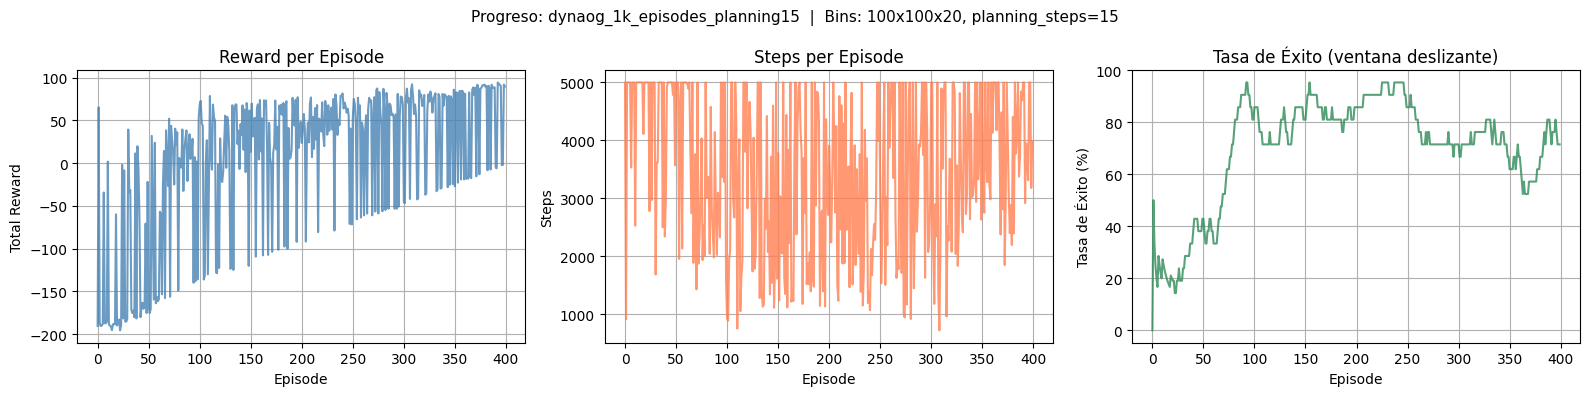

In [32]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
id_d12 = "dynaog_1k_episodes_planning15"
dyna_manager.train_run(
    env=env,
    run_id=id_d12,
    x_bins=100, vel_bins=100, action_bins=20,
    planning_steps=15,
    episodes=400,
    alpha=0.05,
    gamma=0.99,
    epsilon_start=0.99,
    epsilon_end=0.0005,
    max_steps=5000,
)
env.close()
dyna_manager.plot_training_history(id_d12)

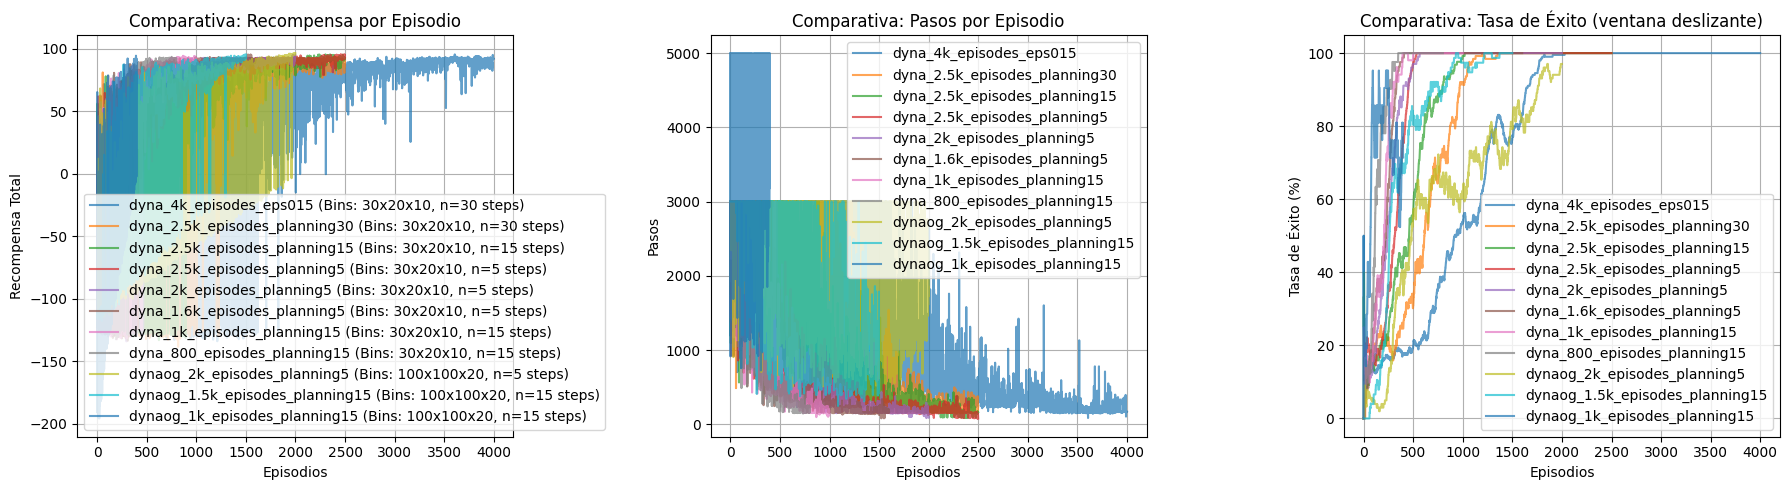

In [33]:
dyna_manager.plot_comparisons()

# Evaluancion de rendimiento

In [ ]:
from hyperparameter_evaluator import HyperparameterEvaluator
from subprocess import run

ql_eval   = HyperparameterEvaluator(manager)       
dyna_eval = HyperparameterEvaluator(dyna_manager)  

## Q-learning

### Epsilon End

In [35]:
id_qe1 = "ql_eps_001"
id_qe2 = "ql_eps_01"
id_qe3 = "ql_eps_05"

Entrenando agente Q-Learning...

[ql_eps_001] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_eps_001] Ep 800/4000 - Avg Reward: -95.31, Steps: 3000
[ql_eps_001] Ep 1600/4000 - Avg Reward: -60.97, Steps: 3000
[ql_eps_001] Ep 2400/4000 - Avg Reward: 35.11, Steps: 1148
[ql_eps_001] Ep 3200/4000 - Avg Reward: 87.59, Steps: 228
[ql_eps_001] Ep 4000/4000 - Avg Reward: 92.35, Steps: 141
--> Experimento 'ql_eps_001' guardado con éxito en el historial.


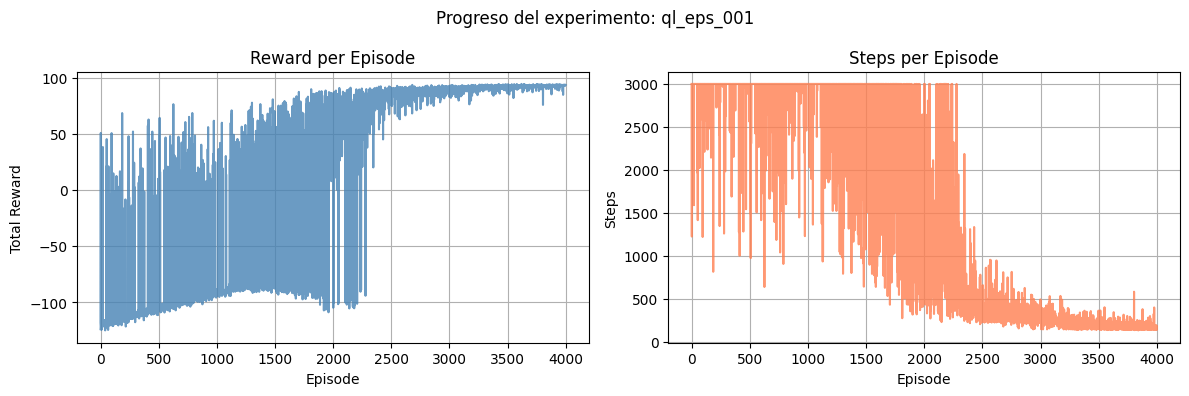

In [36]:

print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qe1,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qe1)

Entrenando agente Q-Learning...

[ql_eps_01] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_eps_01] Ep 800/4000 - Avg Reward: -95.49, Steps: 3000
[ql_eps_01] Ep 1600/4000 - Avg Reward: -58.18, Steps: 2357
[ql_eps_01] Ep 2400/4000 - Avg Reward: 45.64, Steps: 1633
[ql_eps_01] Ep 3200/4000 - Avg Reward: 86.11, Steps: 273
[ql_eps_01] Ep 4000/4000 - Avg Reward: 92.76, Steps: 363
--> Experimento 'ql_eps_01' guardado con éxito en el historial.


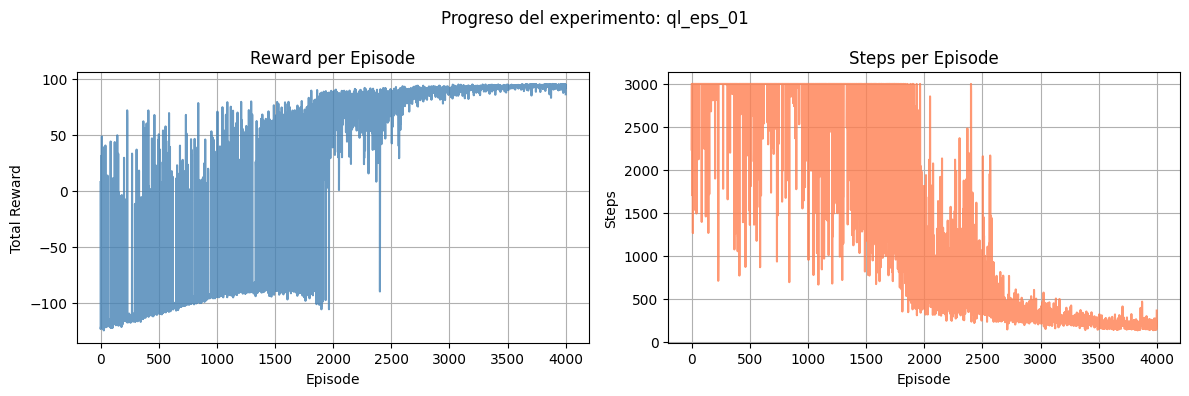

In [37]:
print("Entrenando agente Q-Learning...")
manager.train_run(
    env, 
    run_id=id_qe2,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99,
    epsilon_end=0.01,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qe2)

Entrenando agente Q-Learning...

[ql_eps_05] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_eps_05] Ep 800/4000 - Avg Reward: -97.08, Steps: 3000
[ql_eps_05] Ep 1600/4000 - Avg Reward: -50.54, Steps: 2067
[ql_eps_05] Ep 2400/4000 - Avg Reward: 37.55, Steps: 2636
[ql_eps_05] Ep 3200/4000 - Avg Reward: 81.22, Steps: 238
[ql_eps_05] Ep 4000/4000 - Avg Reward: 91.69, Steps: 168
--> Experimento 'ql_eps_05' guardado con éxito en el historial.


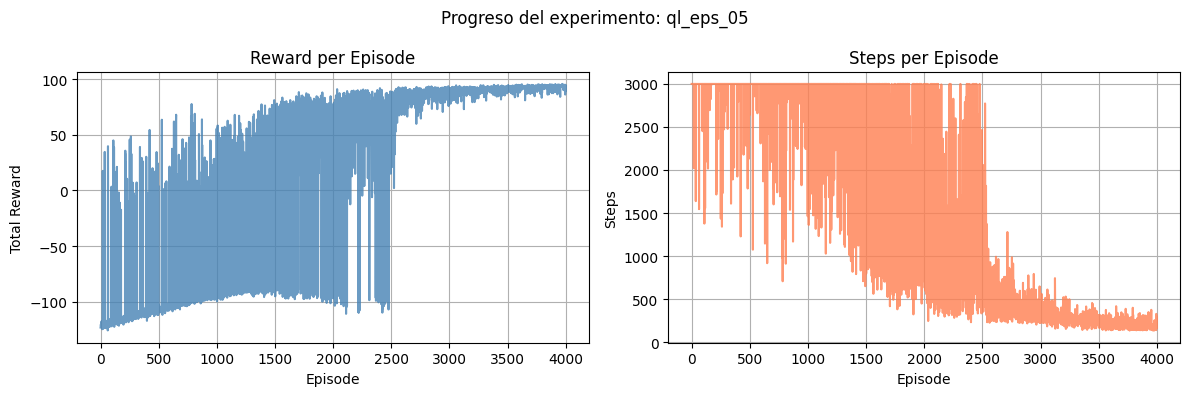

In [38]:
print("Entrenando agente Q-Learning...")
manager.train_run(
    env, 
    run_id=id_qe3,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99,
    epsilon_end=0.05,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qe3)

#### Evaluación

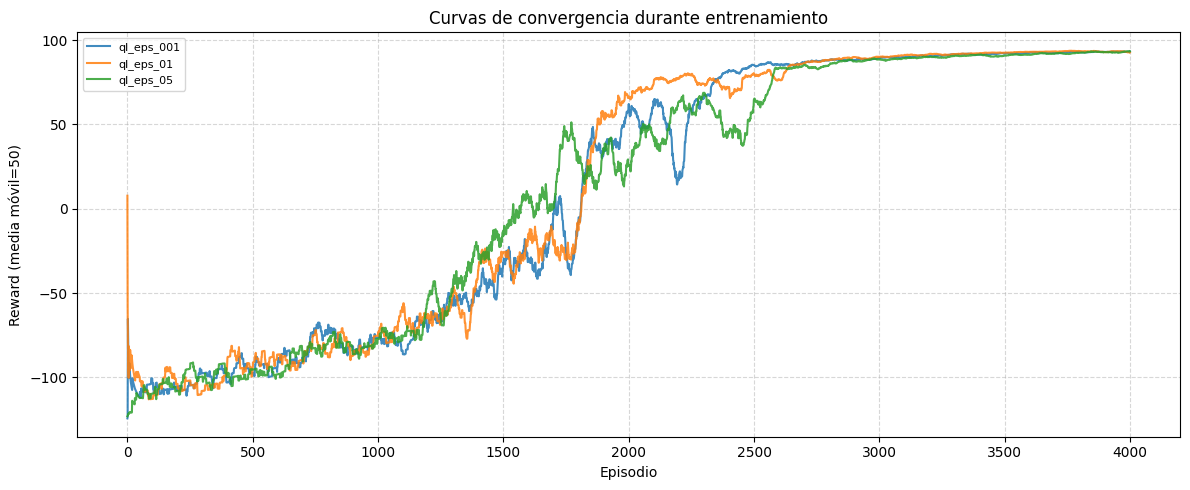

Ejecutá evaluate() primero.


In [ ]:
ql_eval.plot_convergence_curves(run_ids=[id_qe1, id_qe2, id_qe3])


=== Evaluando 3 experimento(s), 10 episodios c/u ===
  [ql_eps_001] avg_reward=93.31 ± 0.66 | success=100% | avg_steps=164
  [ql_eps_01] avg_reward=93.01 ± 1.61 | success=100% | avg_steps=176
  [ql_eps_05] avg_reward=94.31 ± 0.49 | success=100% | avg_steps=164
=== Evaluación completada ===



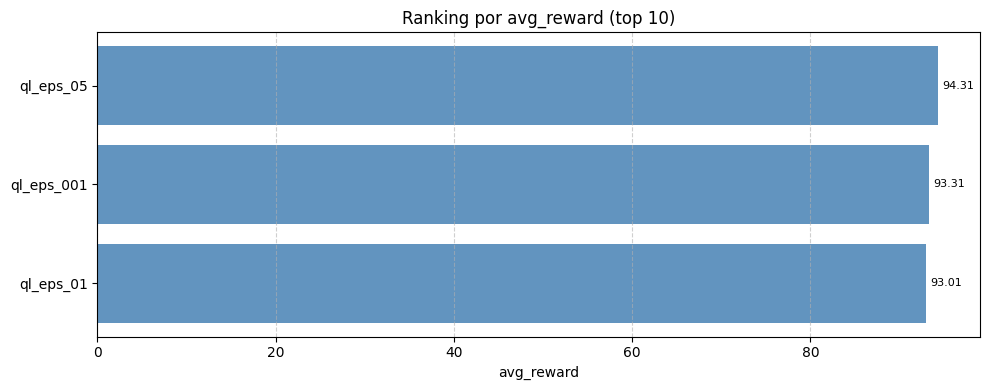

In [ ]:

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
ql_eval.evaluate(env, run_ids=[id_qe1, id_qe2, id_qe3], episodes=10)
env.close()

ql_eval.plot_ranking(run_ids=[id_qe1, id_qe2, id_qe3])

In [41]:
ql_eval.print_full_report(run_ids=[id_qe1, id_qe2, id_qe3])


         REPORTE DE EVALUACIÓN DE HIPERPARÁMETROS

--- Top 5 por avg_reward ---
run_id                                avg_reward  std_reward  success  avg_steps  params
------------------------------------------------------------------------------------------------------------
ql_eps_05                                  94.31        0.49     100%        164  x_bins=30  vel_bins=20  action_bins=10  alpha=0.05
ql_eps_001                                 93.31        0.66     100%        164  x_bins=30  vel_bins=20  action_bins=10  alpha=0.05
ql_eps_01                                  93.01        1.61     100%        176  x_bins=30  vel_bins=20  action_bins=10  alpha=0.05

--- Velocidad de convergencia (umbral reward > 0) ---
  ql_eps_001                          episodio 1703
  ql_eps_01                           episodio 1812
  ql_eps_05                           episodio 1539

--- Estabilidad final (std últimos 200 ep de entrenamiento) ---
  ql_eps_001                          std=1.73

## Alpha

In [42]:
id_qa1= "ql_alpha_001"
id_qa2= "ql_alpha_005"
id_qa3= "ql_alpha_01"

Entrenando agente Q-Learning...

[ql_alpha_001] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_alpha_001] Ep 800/4000 - Avg Reward: -96.22, Steps: 3000
[ql_alpha_001] Ep 1600/4000 - Avg Reward: -78.52, Steps: 3000
[ql_alpha_001] Ep 2400/4000 - Avg Reward: -53.82, Steps: 3000
[ql_alpha_001] Ep 3200/4000 - Avg Reward: -34.03, Steps: 3000
[ql_alpha_001] Ep 4000/4000 - Avg Reward: -15.53, Steps: 3000
--> Experimento 'ql_alpha_001' guardado con éxito en el historial.


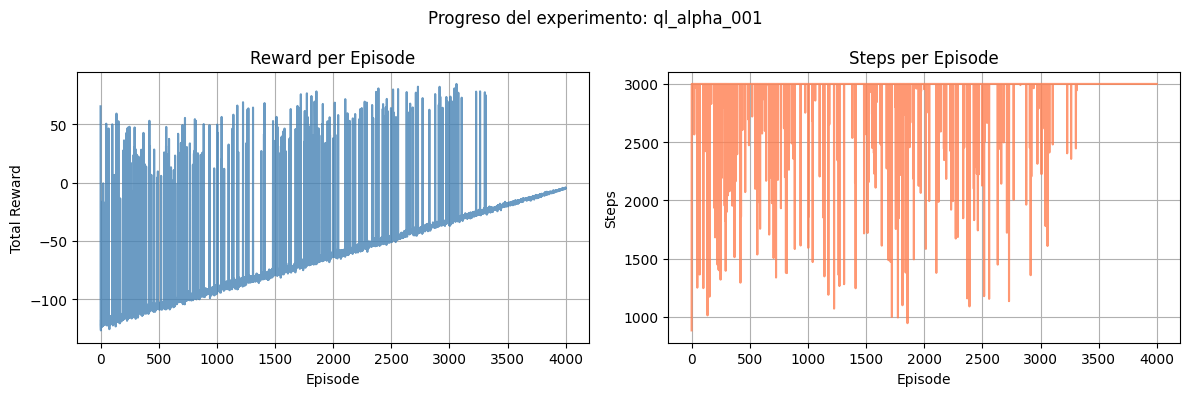

In [43]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qa1,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.01,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qa1)

Entrenando agente Q-Learning...

[ql_alpha_005] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_alpha_005] Ep 800/4000 - Avg Reward: -95.85, Steps: 3000
[ql_alpha_005] Ep 1600/4000 - Avg Reward: -53.61, Steps: 3000
[ql_alpha_005] Ep 2400/4000 - Avg Reward: 35.12, Steps: 647
[ql_alpha_005] Ep 3200/4000 - Avg Reward: 84.26, Steps: 238
[ql_alpha_005] Ep 4000/4000 - Avg Reward: 91.03, Steps: 165
--> Experimento 'ql_alpha_005' guardado con éxito en el historial.


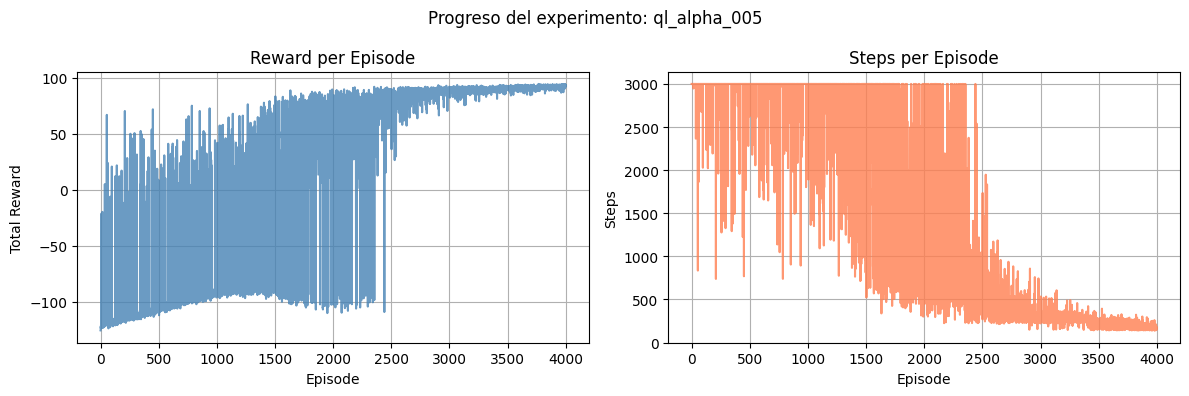

In [44]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qa2,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qa2)

Entrenando agente Q-Learning...

[ql_alpha_01] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_alpha_01] Ep 800/4000 - Avg Reward: -96.93, Steps: 2337
[ql_alpha_01] Ep 1600/4000 - Avg Reward: -82.05, Steps: 3000
[ql_alpha_01] Ep 2400/4000 - Avg Reward: 11.45, Steps: 144
[ql_alpha_01] Ep 3200/4000 - Avg Reward: 87.78, Steps: 170
[ql_alpha_01] Ep 4000/4000 - Avg Reward: 91.87, Steps: 131
--> Experimento 'ql_alpha_01' guardado con éxito en el historial.


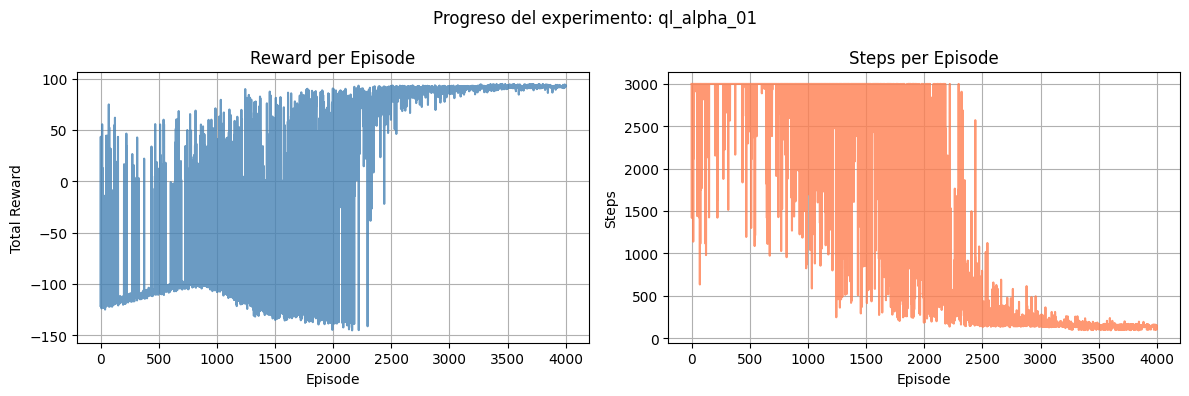

In [45]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qa3,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qa3)

#### Evaluación

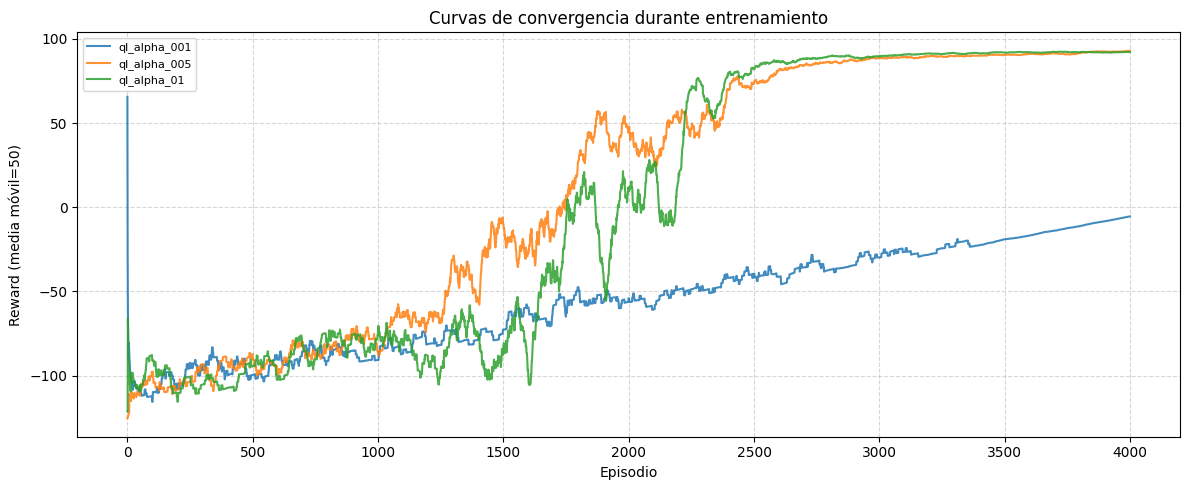

In [46]:
ql_eval.plot_convergence_curves(run_ids=[id_qa1, id_qa2, id_qa3])


=== Evaluando 3 experimento(s), 10 episodios c/u ===
  [ql_alpha_001] avg_reward=-9.21 ± 2.14 | success=0% | avg_steps=4000
  [ql_alpha_005] avg_reward=93.47 ± 0.99 | success=100% | avg_steps=155
  [ql_alpha_01] avg_reward=43.00 ± 147.67 | success=90% | avg_steps=522
=== Evaluación completada ===



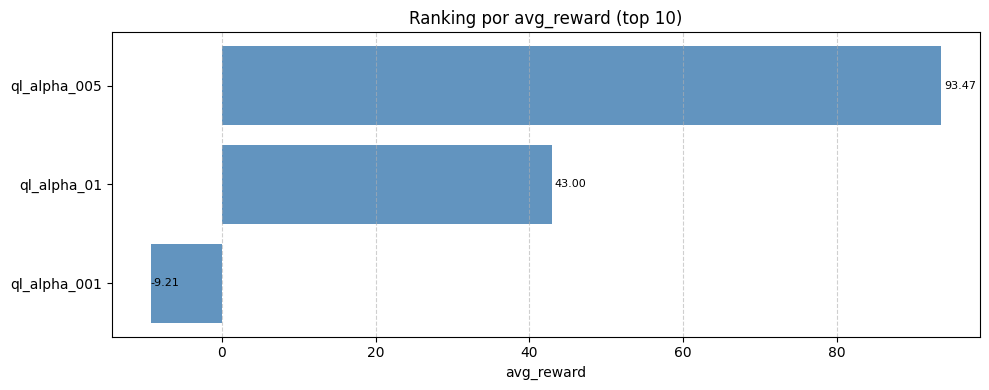

In [47]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
ql_eval.evaluate(env, run_ids=[id_qa1, id_qa2, id_qa3], episodes=10)
env.close()

ql_eval.plot_ranking(run_ids=[id_qa1, id_qa2, id_qa3])

In [48]:
ql_eval.print_full_report(run_ids=[id_qa1, id_qa2, id_qa3])


         REPORTE DE EVALUACIÓN DE HIPERPARÁMETROS

--- Top 5 por avg_reward ---
run_id                                avg_reward  std_reward  success  avg_steps  params
------------------------------------------------------------------------------------------------------------
ql_alpha_005                               93.47        0.99     100%        155  x_bins=30  vel_bins=20  action_bins=10  alpha=0.05
ql_alpha_01                                43.00      147.67      90%        522  x_bins=30  vel_bins=20  action_bins=10  alpha=0.1
ql_alpha_001                               -9.21        2.14       0%       4000  x_bins=30  vel_bins=20  action_bins=10  alpha=0.01

--- Velocidad de convergencia (umbral reward > 0) ---
  ql_alpha_001                        episodio no convergió
  ql_alpha_005                        episodio 1725
  ql_alpha_01                         episodio 1755

--- Estabilidad final (std últimos 200 ep de entrenamiento) ---
  ql_alpha_01                         s

## Action Bins

In [49]:
id_qab1="ql_ab5"
id_qab2="ql_ab10"
id_qab3="ql_ab15"
id_qab4="ql_ab20"

Entrenando agente Q-Learning...

[ql_ab5] Iniciando experimento con Q-Table de tamaño: (31, 21, 5)
[ql_ab5] Ep 800/4000 - Avg Reward: -111.47, Steps: 3000
[ql_ab5] Ep 1600/4000 - Avg Reward: -48.63, Steps: 208
[ql_ab5] Ep 2400/4000 - Avg Reward: 54.95, Steps: 386
[ql_ab5] Ep 3200/4000 - Avg Reward: 85.49, Steps: 130
[ql_ab5] Ep 4000/4000 - Avg Reward: 89.05, Steps: 97
--> Experimento 'ql_ab5' guardado con éxito en el historial.


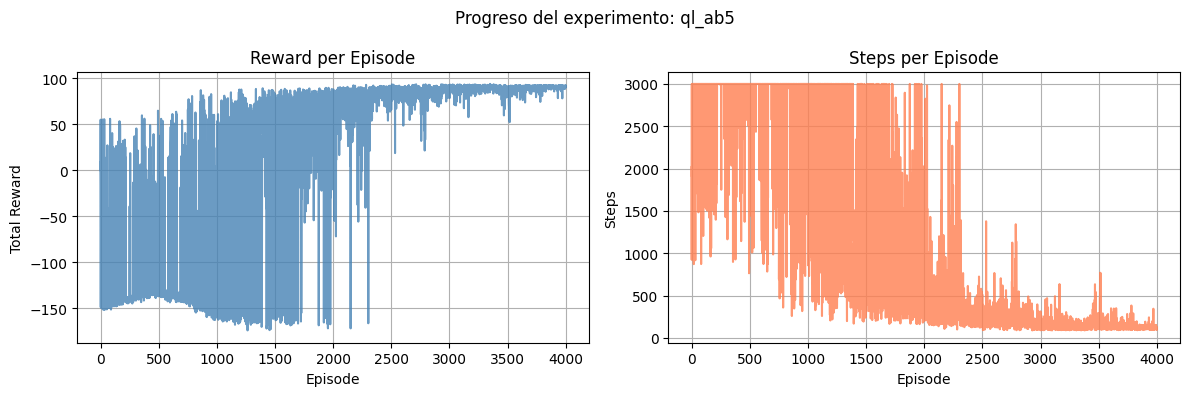

In [50]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qab1,
    x_bins=30,         
    vel_bins=20,       
    action_bins=5,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qab1)

Entrenando agente Q-Learning...

[ql_ab10] Iniciando experimento con Q-Table de tamaño: (31, 21, 10)
[ql_ab10] Ep 800/4000 - Avg Reward: -97.15, Steps: 3000
[ql_ab10] Ep 1600/4000 - Avg Reward: -83.04, Steps: 2965
[ql_ab10] Ep 2400/4000 - Avg Reward: 3.63, Steps: 906
[ql_ab10] Ep 3200/4000 - Avg Reward: 85.61, Steps: 146
[ql_ab10] Ep 4000/4000 - Avg Reward: 90.50, Steps: 104
--> Experimento 'ql_ab10' guardado con éxito en el historial.


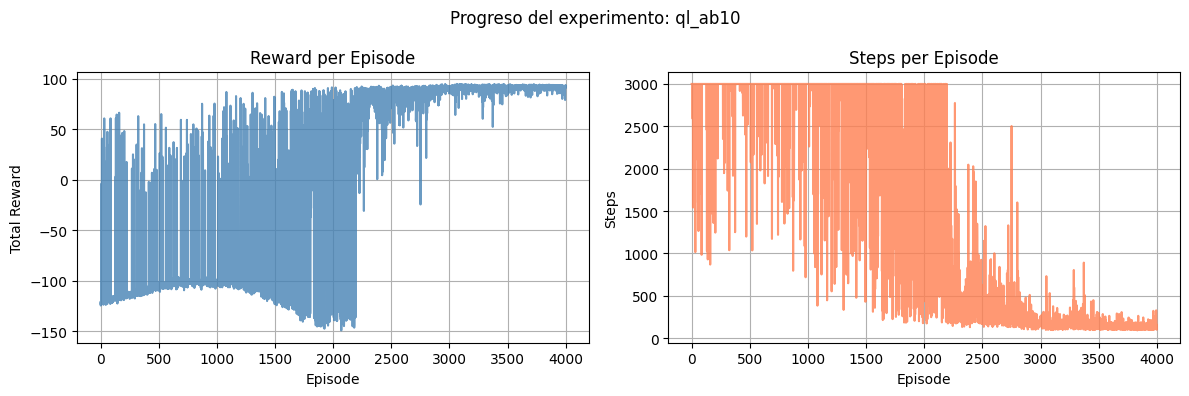

In [51]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qab2,
    x_bins=30,         
    vel_bins=20,       
    action_bins=10,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qab2)

Entrenando agente Q-Learning...

[ql_ab15] Iniciando experimento con Q-Table de tamaño: (31, 21, 15)
[ql_ab15] Ep 800/4000 - Avg Reward: -95.03, Steps: 3000
[ql_ab15] Ep 1600/4000 - Avg Reward: -68.83, Steps: 3000
[ql_ab15] Ep 2400/4000 - Avg Reward: 25.00, Steps: 286
[ql_ab15] Ep 3200/4000 - Avg Reward: 82.29, Steps: 253
[ql_ab15] Ep 4000/4000 - Avg Reward: 92.05, Steps: 145
--> Experimento 'ql_ab15' guardado con éxito en el historial.


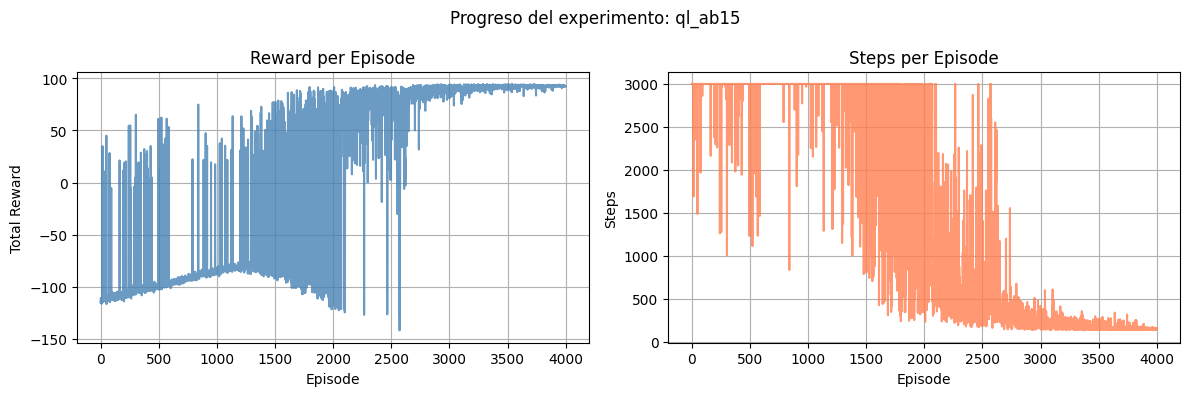

In [52]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qab3,
    x_bins=30,         
    vel_bins=20,       
    action_bins=15,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qab3)

Entrenando agente Q-Learning...

[ql_ab20] Iniciando experimento con Q-Table de tamaño: (31, 21, 20)
[ql_ab20] Ep 800/4000 - Avg Reward: -92.04, Steps: 3000
[ql_ab20] Ep 1600/4000 - Avg Reward: -62.95, Steps: 2186
[ql_ab20] Ep 2400/4000 - Avg Reward: 46.24, Steps: 1558
[ql_ab20] Ep 3200/4000 - Avg Reward: 87.27, Steps: 266
[ql_ab20] Ep 4000/4000 - Avg Reward: 92.56, Steps: 171
--> Experimento 'ql_ab20' guardado con éxito en el historial.


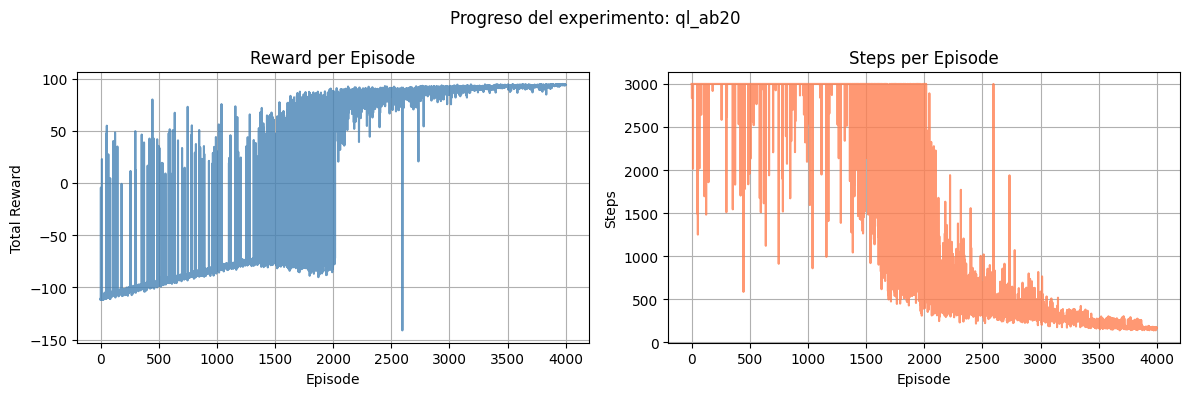

In [53]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qab4,
    x_bins=30,         
    vel_bins=20,       
    action_bins=20,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qab4)

#### Evaluación

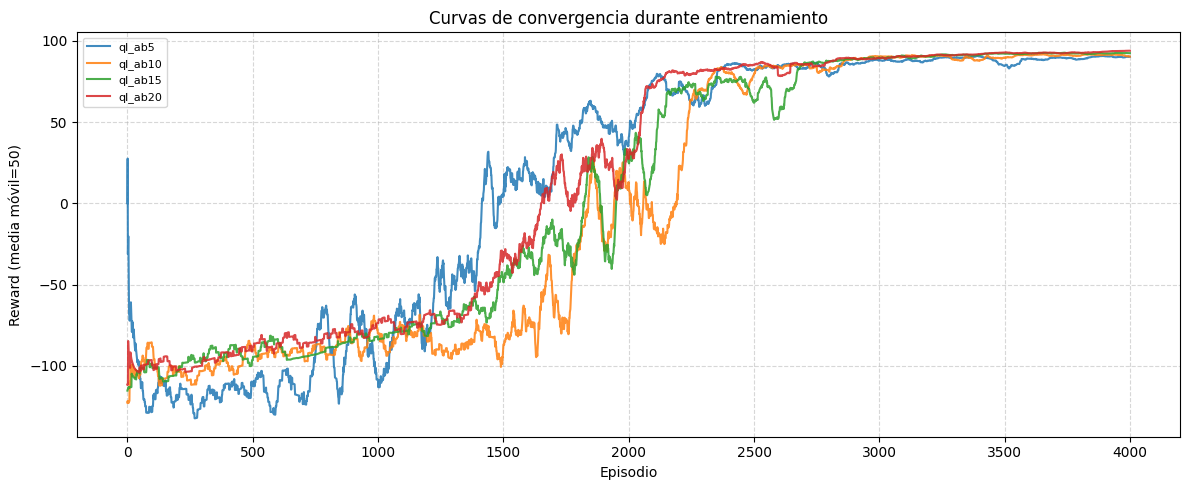

In [54]:
ql_eval.plot_convergence_curves(run_ids=[id_qab1, id_qab2, id_qab3, id_qab4])


=== Evaluando 4 experimento(s), 10 episodios c/u ===
  [ql_ab5] avg_reward=91.09 ± 1.07 | success=100% | avg_steps=114
  [ql_ab10] avg_reward=90.73 ± 3.11 | success=100% | avg_steps=139
  [ql_ab15] avg_reward=92.61 ± 0.38 | success=100% | avg_steps=148
  [ql_ab20] avg_reward=94.16 ± 0.26 | success=100% | avg_steps=164
=== Evaluación completada ===



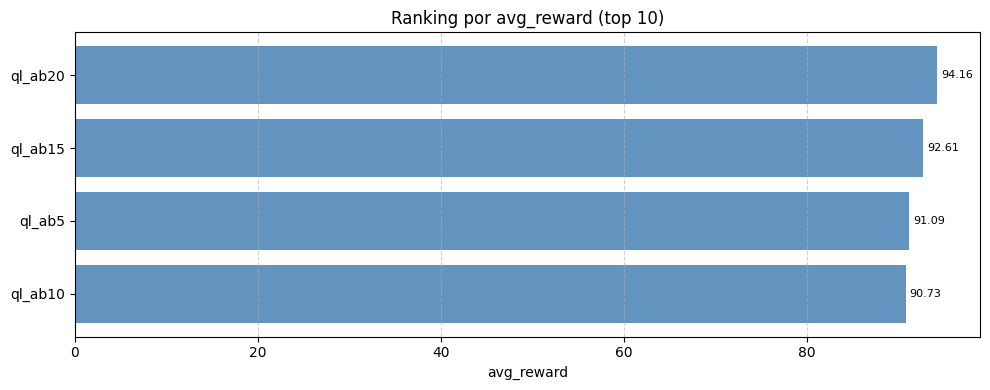

In [55]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
ql_eval.evaluate(env, run_ids=[id_qab1, id_qab2, id_qab3, id_qab4], episodes=10)
env.close()

ql_eval.plot_ranking(run_ids=[id_qab1, id_qab2, id_qab3, id_qab4])

In [56]:
ql_eval.print_full_report(run_ids=[id_qab1, id_qab2, id_qab3, id_qab4])


         REPORTE DE EVALUACIÓN DE HIPERPARÁMETROS

--- Top 5 por avg_reward ---
run_id                                avg_reward  std_reward  success  avg_steps  params
------------------------------------------------------------------------------------------------------------
ql_ab20                                    94.16        0.26     100%        164  x_bins=30  vel_bins=20  action_bins=20  alpha=0.1
ql_ab15                                    92.61        0.38     100%        148  x_bins=30  vel_bins=20  action_bins=15  alpha=0.1
ql_ab5                                     91.09        1.07     100%        114  x_bins=30  vel_bins=20  action_bins=5  alpha=0.1
ql_ab10                                    90.73        3.11     100%        139  x_bins=30  vel_bins=20  action_bins=10  alpha=0.1

--- Velocidad de convergencia (umbral reward > 0) ---
  ql_ab5                              episodio 1415
  ql_ab10                             episodio 1840
  ql_ab15                          

## Con mayor resolusion/granularidad

In [57]:
id_qb1="ql_bins_30x20"
id_qb2="ql_bins_100x100"

Entrenando agente Q-Learning...

[ql_bins_30x20] Iniciando experimento con Q-Table de tamaño: (31, 21, 20)
[ql_bins_30x20] Ep 800/4000 - Avg Reward: -88.13, Steps: 3000
[ql_bins_30x20] Ep 1600/4000 - Avg Reward: -54.79, Steps: 2138
[ql_bins_30x20] Ep 2400/4000 - Avg Reward: 45.36, Steps: 226
[ql_bins_30x20] Ep 3200/4000 - Avg Reward: 84.65, Steps: 262
[ql_bins_30x20] Ep 4000/4000 - Avg Reward: 92.04, Steps: 140
--> Experimento 'ql_bins_30x20' guardado con éxito en el historial.


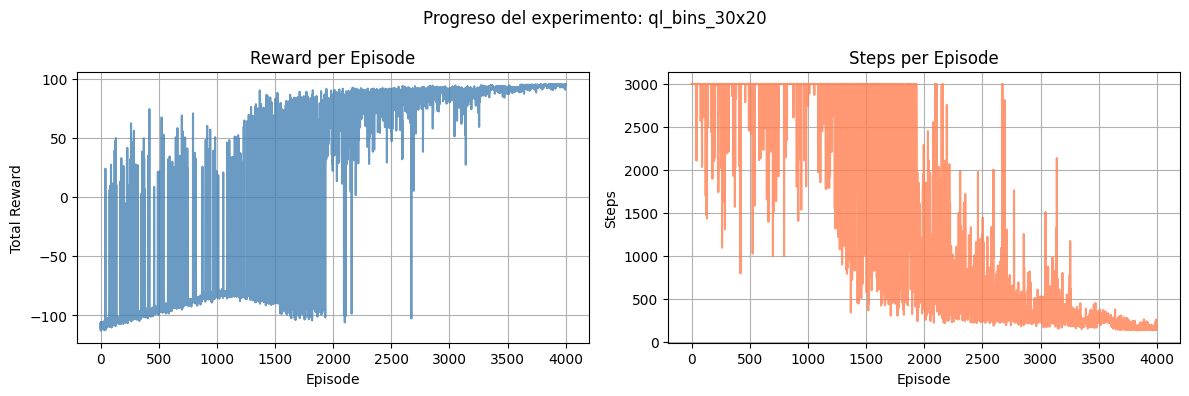

In [58]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qb1,
    x_bins=30,         
    vel_bins=20,       
    action_bins=20,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qb1)

Entrenando agente Q-Learning...

[ql_bins_100x100] Iniciando experimento con Q-Table de tamaño: (101, 101, 20)
[ql_bins_100x100] Ep 800/4000 - Avg Reward: -95.79, Steps: 3000
[ql_bins_100x100] Ep 1600/4000 - Avg Reward: -76.73, Steps: 3000
[ql_bins_100x100] Ep 2400/4000 - Avg Reward: -55.24, Steps: 3000
[ql_bins_100x100] Ep 3200/4000 - Avg Reward: -33.64, Steps: 3000
[ql_bins_100x100] Ep 4000/4000 - Avg Reward: -11.99, Steps: 3000
--> Experimento 'ql_bins_100x100' guardado con éxito en el historial.


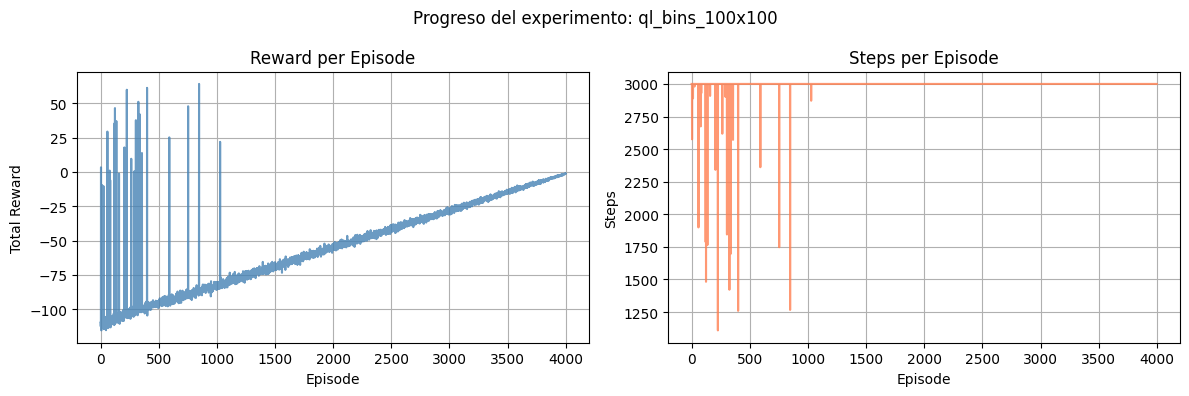

In [59]:
print("Entrenando agente Q-Learning...")

manager.train_run(
    env=env, 
    run_id=id_qb2,
    x_bins=100,         
    vel_bins=100,       
    action_bins=20,    
    episodes=4000,
    alpha=0.1,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.001,
    max_steps=3000
)
env.close()
manager.plot_training_history(id_qb2)

#### Evaluación

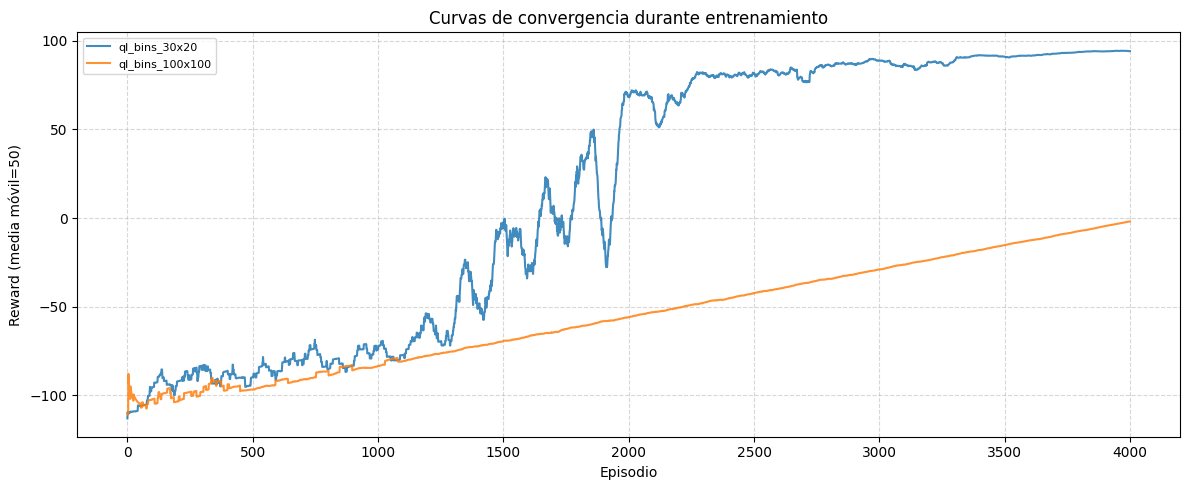

In [60]:
ql_eval.plot_convergence_curves(run_ids=[id_qb1, id_qb2])


=== Evaluando 2 experimento(s), 10 episodios c/u ===
  [ql_bins_30x20] avg_reward=94.53 ± 0.33 | success=100% | avg_steps=169
  [ql_bins_100x100] avg_reward=-1.40 ± 0.07 | success=0% | avg_steps=4000
=== Evaluación completada ===



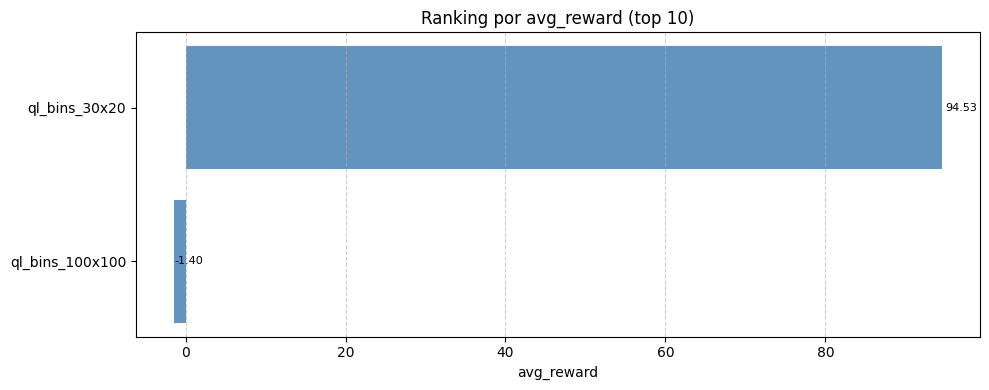

In [61]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
ql_eval.evaluate(env, run_ids=[id_qb1, id_qb2], episodes=10)
env.close()

ql_eval.plot_ranking(run_ids=[id_qb1, id_qb2])

In [62]:
ql_eval.print_full_report(run_ids=[id_qb1, id_qb2])


         REPORTE DE EVALUACIÓN DE HIPERPARÁMETROS

--- Top 5 por avg_reward ---
run_id                                avg_reward  std_reward  success  avg_steps  params
------------------------------------------------------------------------------------------------------------
ql_bins_30x20                              94.53        0.33     100%        169  x_bins=30  vel_bins=20  action_bins=20  alpha=0.1
ql_bins_100x100                            -1.40        0.07       0%       4000  x_bins=100  vel_bins=100  action_bins=20  alpha=0.1

--- Velocidad de convergencia (umbral reward > 0) ---
  ql_bins_30x20                       episodio 1644
  ql_bins_100x100                     episodio no convergió

--- Estabilidad final (std últimos 200 ep de entrenamiento) ---
  ql_bins_30x20                       std=0.829
  ql_bins_100x100                     std=1.644


========== MEJOR CONFIGURACIÓN ==========
  run_id       : ql_bins_30x20
  Parámetros   : {'x_bins': 30, 'vel_bins': 20, 'act

## Seleccion de DynaQ

In [64]:
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
dyna_eval.evaluate(env, episodes=10)
env.close()


=== Evaluando 11 experimento(s), 10 episodios c/u ===
  [dyna_4k_episodes_eps015] avg_reward=91.89 ± 0.41 | success=100% | avg_steps=168
  [dyna_2.5k_episodes_planning30] avg_reward=90.43 ± 1.68 | success=100% | avg_steps=184
  [dyna_2.5k_episodes_planning15] avg_reward=92.29 ± 0.96 | success=100% | avg_steps=163
  [dyna_2.5k_episodes_planning5] avg_reward=93.36 ± 1.04 | success=100% | avg_steps=105
  [dyna_2k_episodes_planning5] avg_reward=63.58 ± 59.89 | success=80% | avg_steps=881
  [dyna_1.6k_episodes_planning5] avg_reward=90.57 ± 0.69 | success=100% | avg_steps=175
  [dyna_1k_episodes_planning15] avg_reward=44.80 ± 148.07 | success=90% | avg_steps=494
  [dyna_800_episodes_planning15] avg_reward=51.24 ± 47.27 | success=60% | avg_steps=1736
  [dynaog_2k_episodes_planning5] avg_reward=-1.14 ± 0.01 | success=0% | avg_steps=4000
  [dynaog_1.5k_episodes_planning15] avg_reward=84.05 ± 28.42 | success=90% | avg_steps=1382
  [dynaog_1k_episodes_planning15] avg_reward=-1.11 ± 0.00 | succes

In [65]:
dyna_eval.print_best()


========== MEJOR CONFIGURACIÓN ==========
  run_id       : dyna_2.5k_episodes_planning5
  Parámetros   : {'x_bins': 30, 'vel_bins': 20, 'action_bins': 10, 'planning_steps': 5, 'alpha': 0.05}
  avg_reward   : 93.36 ± 1.04
  success_rate : 100%
  avg_steps    : 105
  Convergencia : episodio 372
  Estabilidad  : std=2.100 (últimos 200 ep)



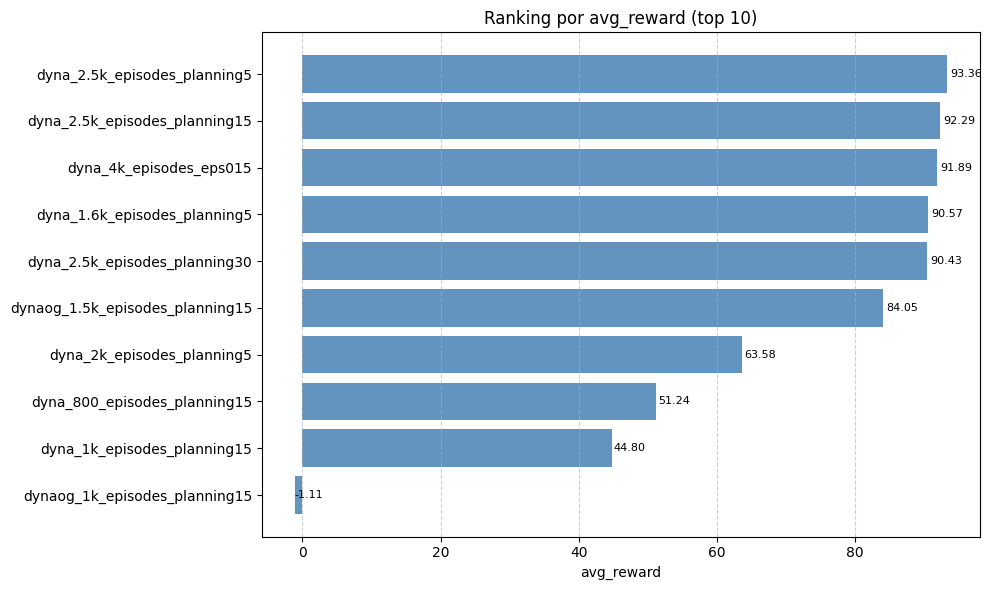

In [66]:
dyna_eval.plot_ranking()

## Comparar ambos

In [ ]:
from hyperparameter_evaluator import HyperparameterEvaluator
evaluator = HyperparameterEvaluator(manager)

In [ ]:
evaluator.get_summary_table()

In [ ]:
evaluator.plot_ranking()

In [ ]:
evaluator.plot_convergence_curves()

In [ ]:
evaluator.plot_reward_vs_steps()

In [ ]:
evaluator.plot_success_rate()

In [ ]:
evaluator.plot_tradeoff()

In [ ]:
evaluator.print_full_report()

In [ ]:
ql_eval.plot_ranking()   # todos los Q-Learning
dyna_eval.plot_ranking() # todos los Dyna-Q

# Anterior Ver si sacar

In [ ]:
from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Q-Learning...")
agent.train_agent(
    env, 
    episodes=8000,
    alpha=0.05,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.15,
    max_steps=3000
)
env.close()

# Visualizar progreso de entrenamiento
agent.plot_training_history()

# Mostrar tasa de éxito en entrenamiento
#train_successes = sum(agent.training_history['successes'])
#print(f"\nÉxitos en entrenamiento: {train_successes}/{len(agent.training_history['successes'])} ({train_successes / len(agent.training_history['successes']) * 100:.1f}%)")

In [ ]:
from dyna_q_agent import DynaQAgent

# Crear agente con configuración inicial
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)

# Entrenar el agente
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
print("Entrenando agente Dyna-Q...")
agent.train_agent(
    env, 
    episodes=5000,
    alpha=0.03,
    gamma=0.99, 
    epsilon_start=0.99, 
    epsilon_end=0.2,
    max_steps=1000,
    planning_steps=20
)
env.close()

# Guardar el modelo entrenado
agent.save_model('dyna_agent_trained.npy')

# Visualizar progreso de entrenamiento
agent.plot_training_history()

In [ ]:
# Continuar entrenamiento a partir del modelo guardado
from dyna_q_agent import DynaQAgent

print("\nContinuando entrenamiento desde el modelo guardado...")
agent = DynaQAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
agent.train_agent(
    env,
    episodes=1500,
    alpha=0.03,
    gamma=0.98,
    epsilon_start=0.1,
    epsilon_end=0.05,
    max_steps=500,
    planning_steps=35
)
env.close()

agent.save_model('dyna_agent_trained_v2.npy')
agent.plot_training_history()
print("Modelo actualizado guardado en dyna_agent_trained_v2.npy")

In [ ]:
# Diagnóstico rápido del modelo cargado
import numpy as np

from q_learning_agent import QLearningAgent

# Crear agente con configuración inicial
agent = QLearningAgent(x_bins=100, vel_bins=100, action_bins=20)
agent.load_model('dyna_agent_trained.npy')

print('Q shape:', getattr(agent, 'Q', None).shape if hasattr(agent, 'Q') else 'no Q')
print('Q sum:', np.sum(agent.Q))
print('Q max:', np.max(agent.Q))
print('Non-zero count:', np.count_nonzero(agent.Q))

# Mostrar los valores de Q para el estado inicial
env = gym.make('MountainCarContinuous-v0', render_mode='rgb_array')
obs, _ = env.reset()
state = agent.discretize_state(obs)
print('Initial observation:', obs)
print('Discretized state:', state)
print('Q[state]:', agent.Q[state])

# Acción determinista según la política actual
action = agent.next_action(state, epsilon=0.0, training=False)
print('Selected action (deterministic):', action)
env.close()